# M4: CT-RATE DINOv2/DINOv3 + ABMIL — Actual CT Volume Experiment

# M4 — CT-RATE Representation Learning, Shared ABMIL, and 18-Label Classification

## Purpose

This notebook is a complete **M4 smoke-test pipeline** for the FYP.

It implements:

**CT-RATE study → selected slices → HU conversion → three-channel CT representation → frozen DINOv2/DINOv3 → slice embeddings → Shared Attention MIL (ABMIL) → study representation → 18-label classifier → evaluation and evidence visualization.**

### Current smoke-test configuration

- 30 training studies
- 10 validation studies
- 16 uniformly selected slices per study
- 224 × 224 input
- frozen DINOv2 ViT-S/14 candidate and DINOv3 candidate
- **Shared ABMIL instead of mean pooling**
- one shared study representation
- one linear prediction head with 18 independent outputs
- `BCEWithLogitsLoss`
- AdamW optimization

This is a **pipeline verification experiment**, not the final FYP benchmark.

### Important CT-RATE correction

The released CT-RATE NIfTI volumes store compact voxel values rather than directly storing HU. CT-RATE metadata provides a per-volume `RescaleSlope` and `RescaleIntercept`.

The notebook therefore performs:

`HU = stored_value × RescaleSlope + RescaleIntercept`

before applying CT windows.

### Important model design

DINO is frozen. The trainable part consists of:

1. Shared ABMIL attention pooling
2. The 18-label prediction head

The ABMIL attention weights are retained as a **slice-level evidence indicator**.

## How to run

1. Open in Google Colab.
2. Select a GPU runtime.
3. Accept access to the gated CT-RATE dataset and DINOv3 model on Hugging Face.
4. Create a Colab Secret named `HF_TOKEN`.
5. Run cells from top to bottom.
6. The selected data are stored under Google Drive so later runs can reuse them.

The notebook intentionally raises clear errors for missing authentication, missing labels, missing intensity-calibration metadata, invalid label values, or non-finite tensors.

## Purpose

This notebook is an M4 smoke-test and development pipeline for CT-RATE. It uses actual CT volumes, converts them to Hounsfield Units, samples a fixed number of slices, extracts frozen DINO features, aggregates slice embeddings with shared ABMIL, and trains an 18-label multi-abnormality classifier.

The current configuration uses **30 training studies and 10 validation studies**. This is still a development-scale experiment, not the final FYP benchmark.


In [31]:
# ============================================================================
# 1. Reproducibility, configuration, and persistent storage
# ============================================================================

from pathlib import Path
import os
import gc
import json
import time
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

# Smoke-test dataset size.
N_TRAIN = 30
N_VAL = 10

# Number of selected axial slices processed per CT study.
K_SLICES = 16

# Spatial input resolution expected by the image encoders.
IMAGE_SIZE = 224

# Frozen feature-extraction batch size.
BATCH_SIZE = 8

# CT-RATE multi-abnormality target count.
NUM_LABELS = 18

# Lightweight ABMIL training configuration.
EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
ABMIL_HIDDEN_DIM = 128

from google.colab import drive
drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate")

RAW_VOLUME_DIR = ROOT / "raw_ct_volumes"
LABEL_DIR = ROOT / "labels"
EMBED_DIR = ROOT / "embeddings"
RESULT_DIR = ROOT / "results"

for directory in [ROOT, RAW_VOLUME_DIR, LABEL_DIR, EMBED_DIR, RESULT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Experiment root:", ROOT)
print("Train studies:", N_TRAIN)
print("Validation studies:", N_VAL)
print("Slices per study:", K_SLICES)
print("Image size:", IMAGE_SIZE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Experiment root: /content/drive/MyDrive/CT_RATE_M4/m4_ct_rate
Train studies: 30
Validation studies: 10
Slices per study: 16
Image size: 224


# Important: CT volumes only

This notebook must use the original CT image volumes, not TotalSegmentator segmentation volumes. The CT-RATE image files are downloaded from `dataset/train_fixed/` and `dataset/valid_fixed/`. A separate `raw_ct_volumes/` directory is used so previously downloaded segmentation files are not reused.



In [32]:
# ============================================================================
# 2. Set deterministic random seeds
# ============================================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

set_seed(SEED)
warnings.filterwarnings("ignore")

print("Random seed:", SEED)

Random seed: 42


In [33]:
def timed_cuda_call(fn):
    """Measure a GPU operation after synchronization to avoid asynchronous timing bias."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()
    result = fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return result, time.perf_counter() - start

In [34]:
# ============================================================================
# 3. Install / verify required packages
# ============================================================================

!pip -q install -U "huggingface_hub>=0.25" "transformers>=4.45" nibabel scikit-learn

## 4. Hugging Face authentication

CT-RATE and DINOv3 require authenticated access in this workflow.

The notebook reads the token from the Colab Secret `HF_TOKEN`. The token is never written into the notebook source.

In [35]:
# ============================================================================
# 4. Authenticate with Hugging Face
# ============================================================================

from huggingface_hub import login

HF_TOKEN = None

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN was not found. Add a Colab Secret named 'HF_TOKEN' "
        "containing a Hugging Face access token."
    )

login(token=HF_TOKEN, add_to_git_credential=False)

print("Hugging Face authentication completed.")

Hugging Face authentication completed.


In [36]:
# ============================================================================
# 5. Download CT-RATE labels and metadata
# ============================================================================

from huggingface_hub import hf_hub_download

CT_RATE_REPO = "ibrahimhamamci/CT-RATE"

def download_dataset_file(remote_path, local_name=None):
    target_name = local_name or Path(remote_path).name
    local_target = LABEL_DIR / target_name

    if local_target.exists() and local_target.stat().st_size > 0:
        print(f"[REUSE] {local_target.name}")
        return local_target

    downloaded = Path(hf_hub_download(
        repo_id=CT_RATE_REPO,
        filename=remote_path,
        repo_type="dataset",
        token=HF_TOKEN,
        local_dir=str(LABEL_DIR),
    ))

    if downloaded != local_target:
        downloaded.replace(local_target)

    print(f"[DOWNLOAD] {remote_path}")
    return local_target

TRAIN_LABEL_CSV = download_dataset_file(
    "dataset/multi_abnormality_labels/train_predicted_labels.csv"
)
VAL_LABEL_CSV = download_dataset_file(
    "dataset/multi_abnormality_labels/valid_predicted_labels.csv"
)
TRAIN_METADATA_CSV = download_dataset_file(
    "dataset/metadata/train_metadata.csv"
)
VAL_METADATA_CSV = download_dataset_file(
    "dataset/metadata/validation_metadata.csv"
)

print("Required CT-RATE CSV files are available.")

[REUSE] train_predicted_labels.csv
[REUSE] valid_predicted_labels.csv
[REUSE] train_metadata.csv
[REUSE] validation_metadata.csv
Required CT-RATE CSV files are available.


In [37]:
# ============================================================================
# 6. Load labels and metadata
# ============================================================================

train_labels = pd.read_csv(TRAIN_LABEL_CSV)
val_labels = pd.read_csv(VAL_LABEL_CSV)

train_metadata = pd.read_csv(TRAIN_METADATA_CSV)
val_metadata = pd.read_csv(VAL_METADATA_CSV)

print("Train labels:", train_labels.shape)
print("Validation labels:", val_labels.shape)
print("Train metadata:", train_metadata.shape)
print("Validation metadata:", val_metadata.shape)

display(train_labels.head())

Train labels: (47149, 19)
Validation labels: (3039, 19)
Train metadata: (47149, 44)
Validation metadata: (3039, 44)


,VolumeName,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
0,train_1_a_1.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
1,train_1_a_2.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
2,train_2_a_1.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
3,train_2_a_2.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
4,train_3_a_1.nii.gz,0,1,1,0,1,0,1,0,0,1,1,1,0,0,1,0,1,0


In [38]:
# ============================================================================
# 7. Validate the exact 18-label abnormality schema
# ============================================================================

LABEL_COLUMNS = [
    "Medical material",
    "Arterial wall calcification",
    "Cardiomegaly",
    "Pericardial effusion",
    "Coronary artery wall calcification",
    "Hiatal hernia",
    "Lymphadenopathy",
    "Emphysema",
    "Atelectasis",
    "Lung nodule",
    "Lung opacity",
    "Pulmonary fibrotic sequela",
    "Pleural effusion",
    "Mosaic attenuation pattern",
    "Peribronchial thickening",
    "Consolidation",
    "Bronchiectasis",
    "Interlobular septal thickening",
]

def find_volume_id_column(df):
    candidates = [
        "VolumeName", "volume_name", "VolumeID", "volume_id",
        "StudyID", "study_id"
    ]

    for column in candidates:
        if column in df.columns:
            return column

    raise ValueError(
        "No volume identifier column found. Available columns: "
        + str(df.columns.tolist())
    )

LABEL_ID_COL = find_volume_id_column(train_labels)

if len(LABEL_COLUMNS) != NUM_LABELS:
    raise AssertionError("Exactly 18 labels are required.")

missing_train = [c for c in LABEL_COLUMNS if c not in train_labels.columns]
missing_val = [c for c in LABEL_COLUMNS if c not in val_labels.columns]

if missing_train or missing_val:
    raise ValueError(
        f"Label schema mismatch. Missing train={missing_train}; "
        f"missing validation={missing_val}"
    )

for split_name, df in [("train", train_labels), ("validation", val_labels)]:
    values = df[LABEL_COLUMNS].to_numpy()

    if np.isnan(values).any():
        raise ValueError(f"{split_name} labels contain NaN values.")

    unique_values = set(np.unique(values).tolist())

    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"{split_name} labels contain values other than 0/1: "
            f"{sorted(unique_values)}"
        )

print("Volume ID column:", LABEL_ID_COL)
print("\nValidated labels:")
for i, label in enumerate(LABEL_COLUMNS, 1):
    print(f"{i:02d}. {label}")

Volume ID column: VolumeName

Validated labels:
01. Medical material
02. Arterial wall calcification
03. Cardiomegaly
04. Pericardial effusion
05. Coronary artery wall calcification
06. Hiatal hernia
07. Lymphadenopathy
08. Emphysema
09. Atelectasis
10. Lung nodule
11. Lung opacity
12. Pulmonary fibrotic sequela
13. Pleural effusion
14. Mosaic attenuation pattern
15. Peribronchial thickening
16. Consolidation
17. Bronchiectasis
18. Interlobular septal thickening


In [39]:
# ============================================================================
# 8. Inspect label prevalence
# ============================================================================

prevalence = train_labels[LABEL_COLUMNS].mean().sort_values(ascending=False)

display(pd.DataFrame({
    "label": prevalence.index,
    "positive_fraction": prevalence.values,
    "positive_percent": prevalence.values * 100,
}))

print(
    "\nThe full training set should be used for the final class-imbalance "
    "analysis. The 10-study smoke test is not sufficient for reliable "
    "prevalence estimates."
)

,label,positive_fraction,positive_percent
0,Lung nodule,0.453498,45.349848
1,Lung opacity,0.369467,36.946701
2,Arterial wall calcification,0.283718,28.371758
3,Pulmonary fibrotic sequela,0.267005,26.700460
4,Atelectasis,0.260090,26.009035
5,Lymphadenopathy,0.259200,25.919956
6,Coronary artery wall calcification,0.255043,25.504252
7,Emphysema,0.193472,19.347176
8,Consolidation,0.176441,17.644065
9,Hiatal hernia,0.143184,14.318437



The full training set should be used for the final class-imbalance analysis. The 10-study smoke test is not sufficient for reliable prevalence estimates.


## 9. Identify CT-RATE intensity calibration metadata

The earlier notebook observed a stored voxel range around `0–117`. That range is a compact stored representation, not a HU range.

For CT-RATE, the required conversion uses the per-volume metadata:

`HU = stored × RescaleSlope + RescaleIntercept`

The abnormality labels remain completely separate from these acquisition/intensity metadata fields.

In [40]:
# ============================================================================
# 9. Locate RescaleSlope and RescaleIntercept
# ============================================================================

def normalized_column_map(df):
    return {
        re.sub(r"[^a-z0-9]", "", str(c).lower()): c
        for c in df.columns
    }

def find_column(df, candidates):
    mapping = normalized_column_map(df)

    for candidate in candidates:
        key = re.sub(r"[^a-z0-9]", "", candidate.lower())
        if key in mapping:
            return mapping[key]

    raise ValueError(
        f"Could not find {candidates}. "
        f"Available columns: {df.columns.tolist()[:100]}"
    )

META_ID_COL = find_column(
    train_metadata,
    ["VolumeName", "volume_name", "VolumeID", "volume_id"]
)

SLOPE_COL = find_column(
    train_metadata,
    ["RescaleSlope", "rescale_slope", "Rescale Slope"]
)

INTERCEPT_COL = find_column(
    train_metadata,
    ["RescaleIntercept", "rescale_intercept", "Rescale Intercept"]
)

print("Metadata ID:", META_ID_COL)
print("Slope:", SLOPE_COL)
print("Intercept:", INTERCEPT_COL)

display(
    train_metadata[[META_ID_COL, SLOPE_COL, INTERCEPT_COL]].head()
)

Metadata ID: VolumeName
Slope: RescaleSlope
Intercept: RescaleIntercept


,VolumeName,RescaleSlope,RescaleIntercept
0,train_1_a_1.nii.gz,1,-8192
1,train_1_a_2.nii.gz,1,-8192
2,train_2_a_1.nii.gz,1,-8192
3,train_2_a_2.nii.gz,1,-8192
4,train_3_a_1.nii.gz,1,-8192


## 10. Select a reproducible smoke-test subset

Train and validation studies are sampled separately from their respective CT-RATE label tables.

The fixed seed makes the smoke test reproducible.

In [41]:
# ============================================================================
# 10. Reproducibly select training and validation studies
# ============================================================================

train_sample = train_labels.sample(
    n=N_TRAIN,
    random_state=SEED
).reset_index(drop=True)

val_sample = val_labels.sample(
    n=N_VAL,
    random_state=SEED
).reset_index(drop=True)

selected_train_ids = train_sample[LABEL_ID_COL].astype(str).tolist()
selected_val_ids = val_sample[LABEL_ID_COL].astype(str).tolist()

print("Training IDs:")
print(*selected_train_ids, sep="\n")

print("\nValidation IDs:")
print(*selected_val_ids, sep="\n")

Training IDs:
train_18373_a_2.nii.gz
train_19287_a_1.nii.gz
train_3282_a_1.nii.gz
train_54_a_2.nii.gz
train_12769_a_2.nii.gz
train_7066_a_1.nii.gz
train_2610_a_2.nii.gz
train_9742_b_2.nii.gz
train_11431_a_1.nii.gz
train_7613_b_1.nii.gz
train_644_d_1.nii.gz
train_13314_a_2.nii.gz
train_8278_b_2.nii.gz
train_1117_b_1.nii.gz
train_14817_a_1.nii.gz
train_7519_a_1.nii.gz
train_7885_a_1.nii.gz
train_8907_b_2.nii.gz
train_10455_a_2.nii.gz
train_7392_a_2.nii.gz
train_19972_c_2.nii.gz
train_16252_a_1.nii.gz
train_18102_a_1.nii.gz
train_6022_a_2.nii.gz
train_15635_a_2.nii.gz
train_6160_c_2.nii.gz
train_19885_d_2.nii.gz
train_14325_a_2.nii.gz
train_16861_b_1.nii.gz
train_4514_a_1.nii.gz

Validation IDs:
valid_130_a_1.nii.gz
valid_1186_a_1.nii.gz
valid_63_a_2.nii.gz
valid_230_a_2.nii.gz
valid_405_a_1.nii.gz
valid_530_a_2.nii.gz
valid_667_a_1.nii.gz
valid_712_a_2.nii.gz
valid_627_a_1.nii.gz
valid_314_a_1.nii.gz


## 11. Construct deterministic CT-RATE repository paths

The CT-RATE repository structure for the downloaded volumes follows the naming convention used below.

This avoids scanning the entire repository just to locate the 13 selected volumes.

In [42]:
# ============================================================================
# 11. Construct remote NIfTI paths
# ============================================================================

def normalize_volume_id(volume_id):
    name = str(volume_id).strip()

    if name.endswith(".nii.gz"):
        return name[:-7]

    if name.endswith(".nii"):
        return name[:-4]

    return name

def ctrate_remote_path(volume_id):
    """
    Return the official CT-RATE path for an original CT volume.

    Important:
    - Training CTs are under dataset/train_fixed/
    - Validation CTs are under dataset/valid_fixed/
    - TotalSegmentator files under dataset/ts_seg/ts_total/ are segmentation volumes
      and must never be used as model input in this notebook.
    """
    stem = normalize_volume_id(volume_id)
    parts = stem.split("_")

    if len(parts) != 4:
        raise ValueError(
            f"Unexpected CT-RATE volume ID format: {volume_id}"
        )

    split_name, patient_id, scan_id, reconstruction_id = parts

    if split_name == "train":
        remote_path = (
            f"dataset/train_fixed/"
            f"train_{patient_id}/train_{patient_id}_{scan_id}/"
            f"{stem}.nii.gz"
        )
    elif split_name == "valid":
        remote_path = (
            f"dataset/valid_fixed/"
            f"valid_{patient_id}/valid_{patient_id}_{scan_id}/"
            f"{stem}.nii.gz"
        )
    else:
        raise ValueError(
            f"Unsupported split in volume ID: {volume_id}"
        )

    if "ts_seg" in remote_path or "ts_total" in remote_path:
        raise RuntimeError(
            "Segmentation path detected. Original CT volumes must be used."
        )

    return remote_path

for volume_id in selected_train_ids[:2] + selected_val_ids[:1]:
    print(volume_id)
    print(" ->", ctrate_remote_path(volume_id))

train_18373_a_2.nii.gz
 -> dataset/train_fixed/train_18373/train_18373_a/train_18373_a_2.nii.gz
train_19287_a_1.nii.gz
 -> dataset/train_fixed/train_19287/train_19287_a/train_19287_a_1.nii.gz
valid_130_a_1.nii.gz
 -> dataset/valid_fixed/valid_130/valid_130_a/valid_130_a_1.nii.gz


In [43]:
# ============================================================================
# 12. Download or reuse selected CT volumes
# ============================================================================

def download_ct_volume(volume_id):
    local_path = RAW_VOLUME_DIR / Path(volume_id).name

    if local_path.exists() and local_path.stat().st_size > 0:
        print(f"[REUSE] {local_path.name}")
        return local_path

    remote_path = ctrate_remote_path(volume_id)

    # Safety guard: never download a segmentation volume.
    if "ts_seg" in remote_path or "ts_total" in remote_path:
        raise RuntimeError(
            f"Refusing to download segmentation data: {remote_path}"
        )

    downloaded = Path(hf_hub_download(
        repo_id=CT_RATE_REPO,
        filename=remote_path,
        repo_type="dataset",
        token=HF_TOKEN,
        local_dir=str(RAW_VOLUME_DIR),
    ))

    if downloaded != local_path:
        downloaded.replace(local_path)

    print(f"[DOWNLOAD] {remote_path}")
    return local_path

records = []

for volume_id in selected_train_ids + selected_val_ids:
    path = download_ct_volume(volume_id)

    records.append({
        "volume_id": volume_id,
        "path": str(path),
        "split": "train" if volume_id.startswith("train_") else "validation",
    })

volume_manifest = pd.DataFrame(records)

display(volume_manifest)

[REUSE] train_18373_a_2.nii.gz
[REUSE] train_19287_a_1.nii.gz
[REUSE] train_3282_a_1.nii.gz
[REUSE] train_54_a_2.nii.gz
[REUSE] train_12769_a_2.nii.gz
[REUSE] train_7066_a_1.nii.gz
[REUSE] train_2610_a_2.nii.gz
[REUSE] train_9742_b_2.nii.gz
[REUSE] train_11431_a_1.nii.gz
[REUSE] train_7613_b_1.nii.gz
[REUSE] train_644_d_1.nii.gz
[REUSE] train_13314_a_2.nii.gz
[REUSE] train_8278_b_2.nii.gz
[REUSE] train_1117_b_1.nii.gz
[REUSE] train_14817_a_1.nii.gz
[REUSE] train_7519_a_1.nii.gz
[REUSE] train_7885_a_1.nii.gz
[REUSE] train_8907_b_2.nii.gz
[REUSE] train_10455_a_2.nii.gz
[REUSE] train_7392_a_2.nii.gz
[REUSE] train_19972_c_2.nii.gz
[REUSE] train_16252_a_1.nii.gz
[REUSE] train_18102_a_1.nii.gz
[REUSE] train_6022_a_2.nii.gz
[REUSE] train_15635_a_2.nii.gz
[REUSE] train_6160_c_2.nii.gz
[REUSE] train_19885_d_2.nii.gz
[REUSE] train_14325_a_2.nii.gz
[REUSE] train_16861_b_1.nii.gz
[REUSE] train_4514_a_1.nii.gz
[REUSE] valid_130_a_1.nii.gz
[REUSE] valid_1186_a_1.nii.gz
[REUSE] valid_63_a_2.nii.gz
[R

,volume_id,path,split
0,train_18373_a_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
1,train_19287_a_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
2,train_3282_a_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
3,train_54_a_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
4,train_12769_a_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
5,train_7066_a_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
6,train_2610_a_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
7,train_9742_b_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
8,train_11431_a_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train
9,train_7613_b_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train


In [44]:
# Safety validation: every downloaded file must correspond to an original CT path.
for _, row in volume_manifest.iterrows():
    if not row['path'].endswith('.nii.gz'):
        raise RuntimeError(f"Unexpected file type: {row['path']}")
    if 'ts_seg' in row['path'] or 'ts_total' in row['path']:
        raise RuntimeError(f"Segmentation file detected in manifest: {row['path']}")

print("✓ Manifest validation passed: only original CT-volume paths are present.")

✓ Manifest validation passed: only original CT-volume paths are present.


In [45]:
# ============================================================================
# 13. Attach per-volume CT intensity calibration
# ============================================================================

def prepare_metadata_lookup(metadata_df):
    result = metadata_df[
        [META_ID_COL, SLOPE_COL, INTERCEPT_COL]
    ].copy()

    result["volume_id"] = result[META_ID_COL].astype(str)
    result["rescale_slope"] = pd.to_numeric(
        result[SLOPE_COL],
        errors="coerce"
    )
    result["rescale_intercept"] = pd.to_numeric(
        result[INTERCEPT_COL],
        errors="coerce"
    )

    return result[
        ["volume_id", "rescale_slope", "rescale_intercept"]
    ]

all_metadata = pd.concat(
    [
        prepare_metadata_lookup(train_metadata),
        prepare_metadata_lookup(val_metadata),
    ],
    ignore_index=True
)

volume_manifest = volume_manifest.merge(
    all_metadata,
    on="volume_id",
    how="left",
    validate="one_to_one"
)

if volume_manifest[
    ["rescale_slope", "rescale_intercept"]
].isna().any().any():
    display(
        volume_manifest[
            volume_manifest[
                ["rescale_slope", "rescale_intercept"]
            ].isna().any(axis=1)
        ]
    )

    raise RuntimeError(
        "One or more selected volumes are missing intensity calibration metadata."
    )

display(volume_manifest)

,volume_id,path,split,rescale_slope,rescale_intercept
0,train_18373_a_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-1024
1,train_19287_a_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-1024
2,train_3282_a_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-8192
3,train_54_a_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-1024
4,train_12769_a_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-8192
5,train_7066_a_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-1024
6,train_2610_a_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-8192
7,train_9742_b_2.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-1024
8,train_11431_a_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-1024
9,train_7613_b_1.nii.gz,/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/r...,train,1,-1024


## 14. Load NIfTI volumes and convert stored values to HU

The conversion is performed separately for every CT volume because the calibration parameters are volume-specific.

This is the correction required for the earlier `uint8`, `0–117` observation.

Volume: train_18373_a_2.nii.gz
Stored NIfTI dtype: int16
Stored range: -1024.0 to 1710.0
RescaleSlope: 1
RescaleIntercept: -1024
Converted HU range: -2048.0 to 686.0
HU percentiles: [-2048. -2048. -2048. -2022. -1957. -1062.  -949.  -616.   686.]


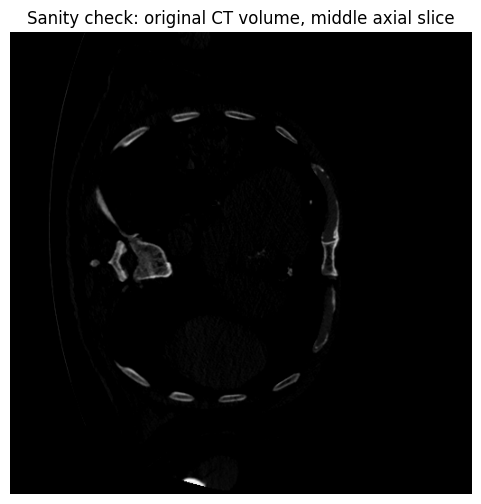

In [46]:
# ============================================================================
# 14. NIfTI loading and stored-value → HU conversion
# ============================================================================

import nibabel as nib

def load_stored_ct(path):
    image = nib.load(str(path))
    image = nib.as_closest_canonical(image)

    stored = image.get_fdata(dtype=np.float32)

    if stored.ndim != 3:
        raise ValueError(
            f"Expected a 3D CT volume; received {stored.shape}"
        )

    if not np.isfinite(stored).all():
        raise ValueError("Stored CT volume contains non-finite values.")

    return stored, image

def stored_to_hu(stored, slope, intercept):
    slope = float(slope)
    intercept = float(intercept)

    if not np.isfinite(slope) or not np.isfinite(intercept):
        raise ValueError("Invalid CT intensity calibration.")

    hu = stored * slope + intercept

    if not np.isfinite(hu).all():
        raise ValueError("HU conversion produced non-finite values.")

    return hu.astype(np.float32)

example = volume_manifest.iloc[0]

stored, nii = load_stored_ct(example["path"])
hu = stored_to_hu(
    stored,
    example["rescale_slope"],
    example["rescale_intercept"]
)

print("Volume:", example["volume_id"])
print("Stored NIfTI dtype:", nii.header.get_data_dtype())
print("Stored range:", float(stored.min()), "to", float(stored.max()))
print("RescaleSlope:", example["rescale_slope"])
print("RescaleIntercept:", example["rescale_intercept"])
print("Converted HU range:", float(hu.min()), "to", float(hu.max()))
hu_percentiles = np.percentile(
    hu, [0, 1, 5, 25, 50, 75, 95, 99, 100]
)

print("HU percentiles:", hu_percentiles)

# Sanity checks designed to catch accidental use of segmentation masks.
if nii.header.get_data_dtype() == np.dtype("uint8"):
    raise RuntimeError(
        "The downloaded file is uint8. This is suspicious for a CT image and "
        "may indicate that a segmentation volume was downloaded."
    )

if float(np.percentile(hu, 99)) < -800:
    raise RuntimeError(
        "The converted volume contains almost no normal CT intensity range. "
        "This strongly suggests that the input is not an original CT volume. "
        "Check the CT-RATE remote path."
    )

# Visual inspection of the middle axial slice.
middle_slice = hu[:, :, hu.shape[2] // 2]

plt.figure(figsize=(6, 6))
plt.imshow(middle_slice, cmap="gray", vmin=-1000, vmax=400)
plt.title("Sanity check: original CT volume, middle axial slice")
plt.axis("off")
plt.show()

In [47]:
# Sanity-check the converted volume before feature extraction.
hu_min = float(np.percentile(hu, 0.5))
hu_max = float(np.percentile(hu, 99.5))
hu_mean = float(np.mean(hu))

print(f"HU 0.5th percentile: {hu_min:.1f}")
print(f"HU 99.5th percentile: {hu_max:.1f}")
print(f"HU mean: {hu_mean:.1f}")

if hu_max < -800:
    raise RuntimeError(
        "The volume does not look like a valid CT image. "
        "Check that a train_fixed/valid_fixed CT volume, not segmentation data, was loaded."
    )

HU 0.5th percentile: -2048.0
HU 99.5th percentile: -447.0
HU mean: -1596.9


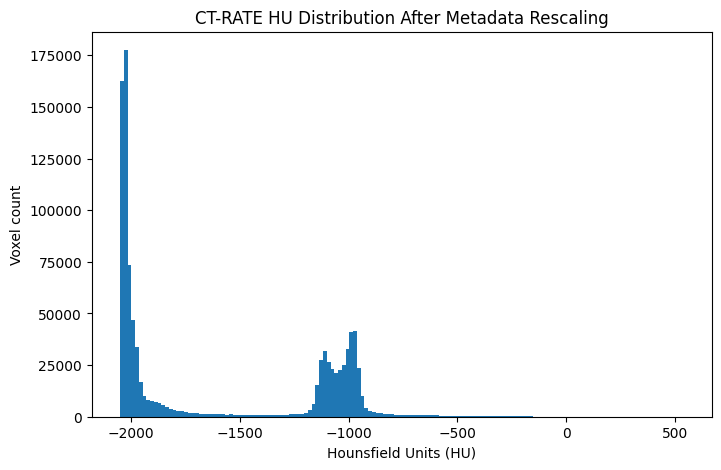

HU sanity check completed.


In [48]:
# ============================================================================
# 15. Visualize the converted HU distribution
# ============================================================================

sample_values = hu.ravel()

if sample_values.size > 1_000_000:
    sample_values = np.random.default_rng(SEED).choice(
        sample_values,
        size=1_000_000,
        replace=False
    )

plt.figure(figsize=(8, 5))
plt.hist(sample_values, bins=150)
plt.title("CT-RATE HU Distribution After Metadata Rescaling")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Voxel count")
plt.show()

print("HU sanity check completed.")

# 16. Three-channel CT representation

The same axial CT slice is represented using three HU windows:

| Channel | Window | Main information |
|---|---|---|
| 1 | `[-1000, 400]` | lung / pulmonary contrast |
| 2 | `[-150, 250]` | soft-tissue / mediastinal contrast |
| 3 | `[-1000, 1000]` | wide-tissue representation |

For each window:

1. clip HU values,
2. linearly map the window to `[0, 1]`,
3. stack the three arrays,
4. resize to `224 × 224`.

The result is a `224 × 224 × 3` image.

The three channels are **three intensity representations of the same slice**, not three neighboring slices.

Image mode: RGB
Image size: (224, 224)


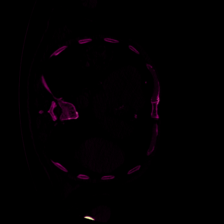

In [49]:
# ============================================================================
# 16. CT windowing and three-channel image construction
# ============================================================================

from PIL import Image

WINDOWS = {
    "lung": (-1000.0, 400.0),
    "soft_tissue": (-150.0, 250.0),
    "wide_tissue": (-1000.0, 1000.0),
}

def window_to_01(hu_slice, low, high):
    clipped = np.clip(hu_slice, low, high)
    return ((clipped - low) / (high - low)).astype(np.float32)

def ct_slice_to_3channel(hu_slice, size=IMAGE_SIZE):
    lung = window_to_01(
        hu_slice,
        *WINDOWS["lung"]
    )

    soft = window_to_01(
        hu_slice,
        *WINDOWS["soft_tissue"]
    )

    wide = window_to_01(
        hu_slice,
        *WINDOWS["wide_tissue"]
    )

    image_3ch = np.stack(
        [lung, soft, wide],
        axis=-1
    )

    image_uint8 = np.clip(
        image_3ch * 255.0,
        0,
        255
    ).astype(np.uint8)

    return Image.fromarray(
        image_uint8,
        mode="RGB"
    ).resize(
        (size, size),
        Image.Resampling.BILINEAR
    )

middle_slice = hu.shape[2] // 2
test_image = ct_slice_to_3channel(
    hu[:, :, middle_slice]
)

print("Image mode:", test_image.mode)
print("Image size:", test_image.size)

display(test_image)

## 17. Temporary uniform slice selection

The final M4 pipeline will consume the slice indices generated by M3.

For this standalone smoke test, uniform sampling is used so that M4 can be validated independently of M3.

The selection function returns exactly `K_SLICES` slices distributed across the axial volume.

In [50]:
# ============================================================================
# 17. Uniform slice selection
# ============================================================================

def select_uniform_slices(num_slices, k=K_SLICES):
    if num_slices < k:
        raise ValueError(
            f"Volume contains {num_slices} slices; K={k} was requested."
        )

    return np.linspace(
        0,
        num_slices - 1,
        num=k,
        dtype=int
    )

print(
    select_uniform_slices(
        hu.shape[2],
        K_SLICES
    )
)

[  0  31  63  95 127 159 191 223 254 286 318 350 382 414 446 478]


# 18. Load frozen DINO backbones

The experiment compares:

- `facebook/dinov2-small`
- `facebook/dinov3-vits16-pretrain-lvd1689m`

Both are used only as frozen feature extractors.

No DINO parameter is updated during ABMIL/classifier training.

In [51]:
# ============================================================================
# 18. Load and freeze DINOv2 and DINOv3
# ============================================================================

import torch
import torch.nn as nn
from transformers import AutoImageProcessor, AutoModel

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DINOV2_ID = "facebook/dinov2-small"
DINOV3_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

def load_frozen_backbone(model_id):
    processor = AutoImageProcessor.from_pretrained(
        model_id,
        token=HF_TOKEN
    )

    model = AutoModel.from_pretrained(
        model_id,
        token=HF_TOKEN
    ).to(DEVICE)

    model.eval()

    for parameter in model.parameters():
        parameter.requires_grad = False

    return processor, model

print("Device:", DEVICE)

v2_processor, v2_model = load_frozen_backbone(DINOV2_ID)
print("DINOv2 loaded.")

v3_processor, v3_model = load_frozen_backbone(DINOV3_ID)
print("DINOv3 loaded.")

print("Both backbones are frozen.")

Device: cuda


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

DINOv3 loaded.
Both backbones are frozen.


In [52]:
# ============================================================================
# 19. Inspect backbone dimensions and parameter counts
# ============================================================================

def model_parameter_count(model):
    return sum(p.numel() for p in model.parameters())

def embedding_dimension(model):
    return int(model.config.hidden_size)

V2_DIM = embedding_dimension(v2_model)
V3_DIM = embedding_dimension(v3_model)

print(f"DINOv2 embedding dimension: {V2_DIM}")
print(f"DINOv3 embedding dimension: {V3_DIM}")

print(
    f"DINOv2 parameters: "
    f"{model_parameter_count(v2_model)/1e6:.2f}M"
)

print(
    f"DINOv3 parameters: "
    f"{model_parameter_count(v3_model)/1e6:.2f}M"
)

DINOv2 embedding dimension: 384
DINOv3 embedding dimension: 384
DINOv2 parameters: 22.06M
DINOv3 parameters: 21.60M


## 20. Frozen slice feature extraction

Each selected slice follows the same preprocessing path:

`HU slice → three CT windows → 224 × 224 × 3 → DINO`

For each study, the result is:

`K × D`

where `K=16` and `D` depends on the backbone.

The features are then cached so future aggregation experiments do not repeatedly run DINO.

In [53]:
# ============================================================================
# 20. Extract frozen embeddings for one study
# ============================================================================

def encode_image_batch(model, processor, images):
    inputs = processor(
        images=images,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(DEVICE)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        outputs = model(**inputs)

    if getattr(outputs, "pooler_output", None) is not None:
        embeddings = outputs.pooler_output
    else:
        embeddings = outputs.last_hidden_state[:, 0]

    return embeddings.float()

def extract_study_embeddings(
    row,
    model,
    processor,
    k=K_SLICES,
    batch_size=BATCH_SIZE
):
    stored, _ = load_stored_ct(row["path"])

    hu = stored_to_hu(
        stored,
        row["rescale_slope"],
        row["rescale_intercept"]
    )

    indices = select_uniform_slices(
        hu.shape[2],
        k
    )

    images = [
        ct_slice_to_3channel(
            hu[:, :, index],
            IMAGE_SIZE
        )
        for index in indices
    ]

    feature_batches = []
    start_time = time.perf_counter()

    for start in range(0, len(images), batch_size):
        batch = images[start:start + batch_size]

        features = encode_image_batch(
            model,
            processor,
            batch
        )

        feature_batches.append(
            features.cpu()
        )

    elapsed = time.perf_counter() - start_time

    embeddings = torch.cat(
        feature_batches,
        dim=0
    ).numpy()

    return embeddings, indices, elapsed

In [54]:
# ============================================================================
# 21. Extract embeddings for the smoke-test dataset
# ============================================================================

def extract_dataset_embeddings(
    manifest,
    model,
    processor,
    backbone_name
):
    embeddings = []
    indices = []
    total_time = 0.0

    for _, row in manifest.iterrows():

        study_embeddings, study_indices, elapsed = (
            extract_study_embeddings(
                row,
                model,
                processor
            )
        )

        embeddings.append(study_embeddings)
        indices.append(study_indices)
        total_time += elapsed

        print(
            f"{backbone_name} | {row['volume_id']} | "
            f"{study_embeddings.shape} | {elapsed:.2f}s"
        )

    return (
        np.stack(embeddings),
        indices,
        total_time
    )

train_manifest = volume_manifest[
    volume_manifest["split"] == "train"
].reset_index(drop=True)

val_manifest = volume_manifest[
    volume_manifest["split"] == "validation"
].reset_index(drop=True)

print("DINOv2 — training features")
v2_train_X, v2_train_indices, v2_train_time = extract_dataset_embeddings(
    train_manifest,
    v2_model,
    v2_processor,
    "DINOv2"
)

print("\nDINOv2 — validation features")
v2_val_X, v2_val_indices, v2_val_time = extract_dataset_embeddings(
    val_manifest,
    v2_model,
    v2_processor,
    "DINOv2"
)

print("\nDINOv3 — training features")
v3_train_X, v3_train_indices, v3_train_time = extract_dataset_embeddings(
    train_manifest,
    v3_model,
    v3_processor,
    "DINOv3"
)

print("\nDINOv3 — validation features")
v3_val_X, v3_val_indices, v3_val_time = extract_dataset_embeddings(
    val_manifest,
    v3_model,
    v3_processor,
    "DINOv3"
)

print("\nFeature shapes:")
print("DINOv2 train:", v2_train_X.shape)
print("DINOv2 val:  ", v2_val_X.shape)
print("DINOv3 train:", v3_train_X.shape)
print("DINOv3 val:  ", v3_val_X.shape)

DINOv2 — training features
DINOv2 | train_18373_a_2.nii.gz | (16, 384) | 0.15s
DINOv2 | train_19287_a_1.nii.gz | (16, 384) | 0.32s
DINOv2 | train_3282_a_1.nii.gz | (16, 384) | 0.17s
DINOv2 | train_54_a_2.nii.gz | (16, 384) | 0.15s
DINOv2 | train_12769_a_2.nii.gz | (16, 384) | 0.17s
DINOv2 | train_7066_a_1.nii.gz | (16, 384) | 0.13s
DINOv2 | train_2610_a_2.nii.gz | (16, 384) | 0.13s
DINOv2 | train_9742_b_2.nii.gz | (16, 384) | 0.13s
DINOv2 | train_11431_a_1.nii.gz | (16, 384) | 0.20s
DINOv2 | train_7613_b_1.nii.gz | (16, 384) | 0.13s
DINOv2 | train_644_d_1.nii.gz | (16, 384) | 0.13s
DINOv2 | train_13314_a_2.nii.gz | (16, 384) | 0.10s
DINOv2 | train_8278_b_2.nii.gz | (16, 384) | 0.14s
DINOv2 | train_1117_b_1.nii.gz | (16, 384) | 0.13s
DINOv2 | train_14817_a_1.nii.gz | (16, 384) | 0.10s
DINOv2 | train_7519_a_1.nii.gz | (16, 384) | 0.13s
DINOv2 | train_7885_a_1.nii.gz | (16, 384) | 0.13s
DINOv2 | train_8907_b_2.nii.gz | (16, 384) | 0.13s
DINOv2 | train_10455_a_2.nii.gz | (16, 384) | 0.14s


In [55]:
# ============================================================================
# 22. Cache frozen features and slice indices
# ============================================================================

np.save(
    EMBED_DIR / "dinov2_train_embeddings.npy",
    v2_train_X
)
np.save(
    EMBED_DIR / "dinov2_val_embeddings.npy",
    v2_val_X
)
np.save(
    EMBED_DIR / "dinov3_train_embeddings.npy",
    v3_train_X
)
np.save(
    EMBED_DIR / "dinov3_val_embeddings.npy",
    v3_val_X
)

for name, values in [
    ("dinov2_train_indices", v2_train_indices),
    ("dinov2_val_indices", v2_val_indices),
    ("dinov3_train_indices", v3_train_indices),
    ("dinov3_val_indices", v3_val_indices),
]:
    np.save(
        EMBED_DIR / f"{name}.npy",
        np.array(values, dtype=object),
        allow_pickle=True
    )

print("Frozen feature cache saved to:", EMBED_DIR)

Frozen feature cache saved to: /content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/embeddings


# 23. Shared Attention MIL (ABMIL)

This cell replaces the previous notebook's mean pooling.

### Mean pooling

`study = mean(slice_1, ..., slice_K)`

Every selected slice contributes equally.

### Shared ABMIL

For each slice embedding `z_i`, a small trainable attention network produces a scalar score.

The scores are normalized:

`alpha_i = softmax(score_i)`

The study representation becomes:

`study = Σ alpha_i z_i`

The same study representation is then passed to the shared 18-label prediction head.

The attention weights are retained as a **slice-level evidence map**.

Only the ABMIL and classifier are trainable; DINO remains frozen.

In [56]:
# ============================================================================
# 23. Shared ABMIL aggregation
# ============================================================================

class SharedABMIL(nn.Module):
    """
    Shared attention-based multiple-instance learning aggregator.

    Input:
        x: [batch, K, D]

    Output:
        pooled: [batch, D]
        attention_weights: [batch, K]
    """

    def __init__(self, embedding_dim, hidden_dim=ABMIL_HIDDEN_DIM):
        super().__init__()

        self.attention_network = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        scores = self.attention_network(x).squeeze(-1)

        attention_weights = torch.softmax(
            scores,
            dim=1
        )

        pooled = torch.sum(
            x * attention_weights.unsqueeze(-1),
            dim=1
        )

        return pooled, attention_weights

# 24. Complete study-level multi-label classifier

The classification head is now explicitly included.

Architecture:

`K slice embeddings → Shared ABMIL → study embedding → Linear(D,18) → 18 logits`

The logits are converted to probabilities with sigmoid **only when evaluating predictions**.

Training uses `BCEWithLogitsLoss`, which combines the sigmoid operation and binary cross-entropy in a numerically stable form.

This is multi-label classification, so there is **no softmax**.

In [57]:
# ============================================================================
# 24. ABMIL + 18-label classification model
# ============================================================================

class ABMILMultiLabelClassifier(nn.Module):
    """
    Study-level multi-label classifier.

    The model contains:
      1. Shared ABMIL aggregation
      2. One linear prediction head with 18 outputs

    DINO features are supplied as frozen inputs and are not part of
    this trainable module.
    """

    def __init__(
        self,
        embedding_dim,
        num_labels=NUM_LABELS,
        hidden_dim=ABMIL_HIDDEN_DIM
    ):
        super().__init__()

        self.aggregation = SharedABMIL(
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim
        )

        self.classifier = nn.Linear(
            embedding_dim,
            num_labels
        )

    def forward(self, x):
        study_representation, attention_weights = self.aggregation(x)

        logits = self.classifier(
            study_representation
        )

        return logits, attention_weights

def trainable_parameter_count(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [58]:
# ============================================================================
# 25. Build the study-level target matrices
# ============================================================================

train_label_lookup = train_labels.set_index(LABEL_ID_COL)
val_label_lookup = val_labels.set_index(LABEL_ID_COL)

train_y = np.stack([
    train_label_lookup.loc[
        volume_id,
        LABEL_COLUMNS
    ].to_numpy(dtype=np.float32)
    for volume_id in train_manifest["volume_id"]
])

val_y = np.stack([
    val_label_lookup.loc[
        volume_id,
        LABEL_COLUMNS
    ].to_numpy(dtype=np.float32)
    for volume_id in val_manifest["volume_id"]
])

print("Training target shape:", train_y.shape)
print("Validation target shape:", val_y.shape)

assert train_y.shape == (N_TRAIN, NUM_LABELS)
assert val_y.shape == (N_VAL, NUM_LABELS)

Training target shape: (30, 18)
Validation target shape: (10, 18)


## 26. Train ABMIL and the 18-label prediction head

The trainable components are:

- ABMIL attention network
- linear 18-label classifier

The frozen DINO representation is not updated.

The optimizer is AdamW and the loss is `BCEWithLogitsLoss`.

In [59]:
# ============================================================================
# 26. Train the lightweight ABMIL + multi-label head
# ============================================================================

from torch.utils.data import TensorDataset, DataLoader

def train_abmil_classifier(
    train_X,
    train_y,
    val_X,
    embedding_dim,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE
):
    model = ABMILMultiLabelClassifier(
        embedding_dim=embedding_dim,
        num_labels=train_y.shape[1],
        hidden_dim=ABMIL_HIDDEN_DIM
    ).to(DEVICE)

    dataset = TensorDataset(
        torch.tensor(train_X, dtype=torch.float32),
        torch.tensor(train_y, dtype=torch.float32)
    )

    loader = DataLoader(
        dataset,
        batch_size=min(8, len(dataset)),
        shuffle=True
    )

    loss_fn = nn.BCEWithLogitsLoss()

    best_state = None
    best_loss = float('inf')

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY
    )

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []

        for batch_X, batch_y in loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()

            logits, _ = model(batch_X)

            loss = loss_fn(
                logits,
                batch_y
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "Non-finite BCE loss detected. "
                    "Check labels and feature values."
                )

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        mean_loss = float(np.mean(losses))
        history.append(mean_loss)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"BCE loss = {mean_loss:.4f}"
        )

    model.eval()

    with torch.inference_mode():
        validation_tensor = torch.tensor(
            val_X,
            dtype=torch.float32,
            device=DEVICE
        )

        logits, attention = model(
            validation_tensor
        )

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy()

        attention = attention.cpu().numpy()

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, probabilities, attention, history

In [60]:
# ============================================================================
# 27. Train DINOv2 + Shared ABMIL + 18-label classifier
# ============================================================================

start = time.perf_counter()

v2_head, v2_val_probs, v2_val_attention, v2_history = (
    train_abmil_classifier(
        train_X=v2_train_X,
        train_y=train_y,
        val_X=v2_val_X,
        embedding_dim=V2_DIM
    )
)

v2_abmil_training_time = time.perf_counter() - start

print(
    f"\nDINOv2 ABMIL training time: "
    f"{v2_abmil_training_time:.2f}s"
)

print(
    "Trainable ABMIL + classifier parameters:",
    f"{trainable_parameter_count(v2_head)/1e3:.2f}K"
)

Epoch 01/10 | BCE loss = 0.7788
Epoch 02/10 | BCE loss = 0.4806
Epoch 03/10 | BCE loss = 0.4220
Epoch 04/10 | BCE loss = 0.4070
Epoch 05/10 | BCE loss = 0.3895
Epoch 06/10 | BCE loss = 0.3690
Epoch 07/10 | BCE loss = 0.3521
Epoch 08/10 | BCE loss = 0.3360
Epoch 09/10 | BCE loss = 0.3271
Epoch 10/10 | BCE loss = 0.3011

DINOv2 ABMIL training time: 0.84s
Trainable ABMIL + classifier parameters: 56.34K


In [61]:
# ============================================================================
# 28. Train DINOv3 + Shared ABMIL + 18-label classifier
# ============================================================================

start = time.perf_counter()

v3_head, v3_val_probs, v3_val_attention, v3_history = (
    train_abmil_classifier(
        train_X=v3_train_X,
        train_y=train_y,
        val_X=v3_val_X,
        embedding_dim=V3_DIM
    )
)

v3_abmil_training_time = time.perf_counter() - start

print(
    f"\nDINOv3 ABMIL training time: "
    f"{v3_abmil_training_time:.2f}s"
)

print(
    "Trainable ABMIL + classifier parameters:",
    f"{trainable_parameter_count(v3_head)/1e3:.2f}K"
)

Epoch 01/10 | BCE loss = 0.6579
Epoch 02/10 | BCE loss = 0.5698
Epoch 03/10 | BCE loss = 0.5075
Epoch 04/10 | BCE loss = 0.4742
Epoch 05/10 | BCE loss = 0.4468
Epoch 06/10 | BCE loss = 0.4360
Epoch 07/10 | BCE loss = 0.4260
Epoch 08/10 | BCE loss = 0.4185
Epoch 09/10 | BCE loss = 0.4194
Epoch 10/10 | BCE loss = 0.4111

DINOv3 ABMIL training time: 0.10s
Trainable ABMIL + classifier parameters: 56.34K


## 29. Evaluate the 18-label predictions

The evaluation reports:

- AUROC
- AUPRC
- macro F1

Labels for which the tiny validation subset contains only one class are excluded from AUROC/AUPRC aggregation rather than producing misleading undefined values.

The final FYP benchmark must use the full held-out validation set.

In [62]:
# ============================================================================
# 29. Robust multi-label evaluation
# ============================================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score
)

def evaluate_multilabel(y_true, y_prob, threshold=0.5):

    aurocs = []
    auprcs = []
    f1s = []
    rows = []

    for index, label in enumerate(LABEL_COLUMNS):

        truth = y_true[:, index]
        probability = y_prob[:, index]
        prediction = (
            probability >= threshold
        ).astype(int)

        label_auroc = np.nan
        label_auprc = np.nan

        if len(np.unique(truth)) == 2:
            label_auroc = roc_auc_score(
                truth,
                probability
            )

            label_auprc = average_precision_score(
                truth,
                probability
            )

            aurocs.append(label_auroc)
            auprcs.append(label_auprc)

        label_f1 = f1_score(
            truth,
            prediction,
            zero_division=0
        )

        f1s.append(label_f1)

        rows.append({
            "label": label,
            "AUROC": label_auroc,
            "AUPRC": label_auprc,
            "F1": label_f1,
            "positive_count": int(truth.sum())
        })

    metrics = {
        "mean_AUROC": float(np.mean(aurocs)) if aurocs else np.nan,
        "mean_AUPRC": float(np.mean(auprcs)) if auprcs else np.nan,
        "macro_F1": float(np.mean(f1s))
    }

    return metrics, pd.DataFrame(rows)

v2_metrics, v2_per_label = evaluate_multilabel(
    val_y,
    v2_val_probs
)

v3_metrics, v3_per_label = evaluate_multilabel(
    val_y,
    v3_val_probs
)

print("DINOv2 + Shared ABMIL")
display(pd.DataFrame([v2_metrics]))

print("\nDINOv3 + Shared ABMIL")
display(pd.DataFrame([v3_metrics]))

DINOv2 + Shared ABMIL


,mean_AUROC,mean_AUPRC,macro_F1
0,0.417292,0.354892,0.037037



DINOv3 + Shared ABMIL


,mean_AUROC,mean_AUPRC,macro_F1
0,0.424005,0.364176,0.0


## 30. Print study-level classification results

The previous evaluation cell reports aggregate metrics such as AUROC, AUPRC, and macro F1. This section also prints the actual classification outputs for each validation study so the experiment can be inspected directly.

For every study, the notebook shows:
- the ground-truth abnormalities,
- the predicted abnormalities at a probability threshold of 0.50,
- the probability assigned to each predicted abnormality,
- and a complete probability table for all 18 labels.

This is useful for qualitative error analysis because a study may contain several simultaneous abnormalities. The output is therefore multi-label rather than a single class prediction.

In [63]:
# ============================================================================
# 30. Print study-level multi-label classification outputs
# ============================================================================

CLASSIFICATION_THRESHOLD = 0.50

def get_positive_labels(probabilities, threshold=CLASSIFICATION_THRESHOLD):
    """Return labels whose predicted probability is at or above the threshold."""
    return [
        LABEL_COLUMNS[i]
        for i, probability in enumerate(probabilities)
        if probability >= threshold
    ]


def get_label_probability_pairs(probabilities, threshold=CLASSIFICATION_THRESHOLD):
    """Return predicted-positive labels together with their probabilities."""
    return [
        (LABEL_COLUMNS[i], float(probability))
        for i, probability in enumerate(probabilities)
        if probability >= threshold
    ]


print("=" * 90)
print("STUDY-LEVEL CLASSIFICATION RESULTS")
print("=" * 90)
print(f"Decision threshold: {CLASSIFICATION_THRESHOLD:.2f}")

for study_index, volume_id in enumerate(val_manifest["volume_id"]):

    actual_labels = [
        LABEL_COLUMNS[i]
        for i, value in enumerate(val_y[study_index])
        if value == 1
    ]

    v2_pairs = get_label_probability_pairs(v2_val_probs[study_index])
    v3_pairs = get_label_probability_pairs(v3_val_probs[study_index])

    print(f"\nStudy: {volume_id}")
    print("CT-RATE reference labels:")
    print(", ".join(actual_labels) if actual_labels else "None")

    print("\nDINOv2 + Shared ABMIL predictions:")
    if v2_pairs:
        for label, probability in v2_pairs:
            print(f"  - {label}: {probability:.4f}")
    else:
        print("  - No label reached the 0.50 threshold")

    print("\nDINOv3 + Shared ABMIL predictions:")
    if v3_pairs:
        for label, probability in v3_pairs:
            print(f"  - {label}: {probability:.4f}")
    else:
        print("  - No label reached the 0.50 threshold")


# Complete probability table: one row per validation study and one column per abnormality.
v2_probability_table = pd.DataFrame(
    v2_val_probs,
    columns=LABEL_COLUMNS,
    index=val_manifest["volume_id"].astype(str)
).reset_index().rename(columns={"index": "volume_id"})

v3_probability_table = pd.DataFrame(
    v3_val_probs,
    columns=LABEL_COLUMNS,
    index=val_manifest["volume_id"].astype(str)
).reset_index().rename(columns={"index": "volume_id"})

print("\n" + "=" * 90)
print("DINOv2 — COMPLETE 18-LABEL PROBABILITY TABLE")
print("=" * 90)
display(v2_probability_table.round(4))

print("\n" + "=" * 90)
print("DINOv3 — COMPLETE 18-LABEL PROBABILITY TABLE")
print("=" * 90)
display(v3_probability_table.round(4))

print("\nNote: a probability is the model's estimated likelihood for that abnormality. "
      "The 0.50 threshold converts probabilities into binary predicted labels. "
      "For the final study, thresholds should be selected using the planned validation protocol "
      "rather than assumed to be optimal.")

STUDY-LEVEL CLASSIFICATION RESULTS
Decision threshold: 0.50

Study: valid_130_a_1.nii.gz
CT-RATE reference labels:
Medical material, Arterial wall calcification, Coronary artery wall calcification, Emphysema, Lung nodule, Lung opacity, Pulmonary fibrotic sequela

DINOv2 + Shared ABMIL predictions:
  - No label reached the 0.50 threshold

DINOv3 + Shared ABMIL predictions:
  - No label reached the 0.50 threshold

Study: valid_1186_a_1.nii.gz
CT-RATE reference labels:
Lung nodule, Lung opacity, Mosaic attenuation pattern

DINOv2 + Shared ABMIL predictions:
  - No label reached the 0.50 threshold

DINOv3 + Shared ABMIL predictions:
  - No label reached the 0.50 threshold

Study: valid_63_a_2.nii.gz
CT-RATE reference labels:
Arterial wall calcification, Coronary artery wall calcification, Lymphadenopathy, Lung nodule, Pleural effusion, Mosaic attenuation pattern, Consolidation

DINOv2 + Shared ABMIL predictions:
  - Medical material: 0.6632

DINOv3 + Shared ABMIL predictions:
  - Pulmonary

,volume_id,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
0,valid_130_a_1.nii.gz,0.0871,0.1138,0.1680,0.0090,0.0764,0.0805,0.3735,0.0731,0.1636,0.4476,0.4129,0.3392,0.0533,0.0042,0.0153,0.3497,0.0013,0.0486
1,valid_1186_a_1.nii.gz,0.2915,0.1012,0.1173,0.0201,0.1600,0.1000,0.0924,0.0726,0.0816,0.2085,0.2782,0.2051,0.1044,0.0137,0.0143,0.3368,0.0007,0.0596
2,valid_63_a_2.nii.gz,0.6632,0.4336,0.3092,0.0039,0.2749,0.1065,0.2664,0.1045,0.0852,0.3253,0.4144,0.2522,0.1197,0.0311,0.0280,0.2584,0.0004,0.1881
3,valid_230_a_2.nii.gz,0.2371,0.2371,0.0020,0.0151,0.1167,0.1060,0.0028,0.0989,0.3053,0.5811,0.4243,0.2224,0.2401,0.0850,0.0581,0.1162,0.0548,0.0032
4,valid_405_a_1.nii.gz,0.0625,0.0632,0.1123,0.0133,0.0318,0.0784,0.2731,0.0390,0.2851,0.3882,0.5079,0.5896,0.0694,0.0111,0.0163,0.2495,0.0012,0.0369
5,valid_530_a_2.nii.gz,0.0739,0.0651,0.1550,0.0153,0.0547,0.0848,0.1195,0.0543,0.1360,0.3134,0.4843,0.3911,0.0779,0.0052,0.0152,0.3992,0.0015,0.0573
6,valid_667_a_1.nii.gz,0.1185,0.1284,0.2301,0.0382,0.0351,0.1624,0.2365,0.0639,0.3300,0.3626,0.5079,0.4509,0.0574,0.0161,0.0205,0.2305,0.0012,0.0450
7,valid_712_a_2.nii.gz,0.5228,0.3757,0.3580,0.0081,0.4693,0.0921,0.1021,0.1520,0.0438,0.3292,0.2953,0.5015,0.1310,0.0142,0.0213,0.4344,0.0021,0.1449
8,valid_627_a_1.nii.gz,0.1217,0.0843,0.1751,0.0120,0.0840,0.0820,0.4117,0.0508,0.2576,0.4195,0.4383,0.7097,0.0600,0.0053,0.0124,0.2555,0.0007,0.0937
9,valid_314_a_1.nii.gz,0.1579,0.1092,0.1895,0.0103,0.0866,0.0763,0.3210,0.0881,0.2217,0.3659,0.4403,0.4128,0.0857,0.0212,0.0233,0.2151,0.0008,0.0633



DINOv3 — COMPLETE 18-LABEL PROBABILITY TABLE


,volume_id,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
0,valid_130_a_1.nii.gz,0.2518,0.2415,0.2111,0.0506,0.2096,0.1083,0.3045,0.1184,0.2031,0.3627,0.4039,0.4952,0.1119,0.0767,0.0653,0.2495,0.0554,0.1650
1,valid_1186_a_1.nii.gz,0.2175,0.2008,0.1835,0.0560,0.1951,0.0908,0.2376,0.1209,0.1679,0.3752,0.3534,0.4571,0.1043,0.0797,0.0780,0.2520,0.0487,0.1741
2,valid_63_a_2.nii.gz,0.2173,0.2288,0.2042,0.0527,0.2193,0.0885,0.2716,0.1569,0.1642,0.3821,0.3402,0.5019,0.1096,0.0722,0.0798,0.2598,0.0541,0.1752
3,valid_230_a_2.nii.gz,0.1799,0.1937,0.0360,0.0842,0.0945,0.1461,0.0333,0.0868,0.3049,0.5980,0.4131,0.1978,0.1675,0.0951,0.1089,0.0890,0.0827,0.0382
4,valid_405_a_1.nii.gz,0.2038,0.2278,0.1898,0.0526,0.2281,0.0951,0.2954,0.1179,0.1618,0.3511,0.4336,0.4864,0.1198,0.0685,0.0761,0.2633,0.0480,0.1548
5,valid_530_a_2.nii.gz,0.2112,0.2291,0.1887,0.0487,0.1917,0.0971,0.2949,0.1085,0.2198,0.3734,0.4264,0.4908,0.1141,0.0678,0.0688,0.2491,0.0497,0.1542
6,valid_667_a_1.nii.gz,0.2093,0.2540,0.2184,0.0540,0.2051,0.0946,0.2837,0.1012,0.1856,0.3717,0.4125,0.4750,0.1096,0.0668,0.0648,0.2602,0.0488,0.1424
7,valid_712_a_2.nii.gz,0.2434,0.2349,0.2271,0.0659,0.1907,0.1032,0.2590,0.1164,0.1608,0.3928,0.3433,0.3862,0.1128,0.0912,0.0696,0.2903,0.0547,0.1913
8,valid_627_a_1.nii.gz,0.2178,0.2599,0.1999,0.0565,0.1883,0.1116,0.2924,0.1231,0.1963,0.4031,0.3747,0.4889,0.1253,0.0625,0.0786,0.2565,0.0510,0.1564
9,valid_314_a_1.nii.gz,0.2498,0.2423,0.2003,0.0453,0.2214,0.0891,0.2777,0.1029,0.1691,0.4091,0.4046,0.4956,0.1109,0.0693,0.0634,0.2735,0.0480,0.1525



Note: a probability is the model's estimated likelihood for that abnormality. The 0.50 threshold converts probabilities into binary predicted labels. For the final study, thresholds should be selected using the planned validation protocol rather than assumed to be optimal.


In [64]:
def print_error_analysis(y_true, y_prob, label_names, threshold=0.50, study_id=None):
    """Print study-level true/false positives and false negatives for inspection."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    tp = [label_names[i] for i in range(len(label_names)) if y_true[i] == 1 and y_pred[i] == 1]
    fp = [f"{label_names[i]} ({y_prob[i]:.3f})" for i in range(len(label_names)) if y_true[i] == 0 and y_pred[i] == 1]
    fn = [f"{label_names[i]} ({y_prob[i]:.3f})" for i in range(len(label_names)) if y_true[i] == 1 and y_pred[i] == 0]

    if study_id is not None:
        print(f"Study: {study_id}")
    print("True positives:", ", ".join(tp) if tp else "None")
    print("False positives:", ", ".join(fp) if fp else "None")
    print("False negatives:", ", ".join(fn) if fn else "None")

## 31. Visualize the learned ABMIL evidence weights

ABMIL produces one attention weight for every selected slice.

A high weight means that the attention module assigned greater importance to that slice when constructing the shared study representation.

This is a **slice-level model evidence indicator**. It is not a pixel-level segmentation and should not be interpreted as a definitive clinical finding.

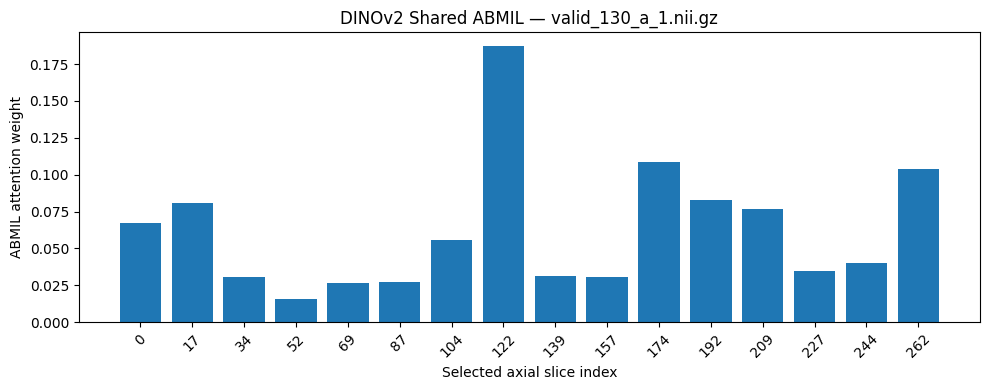

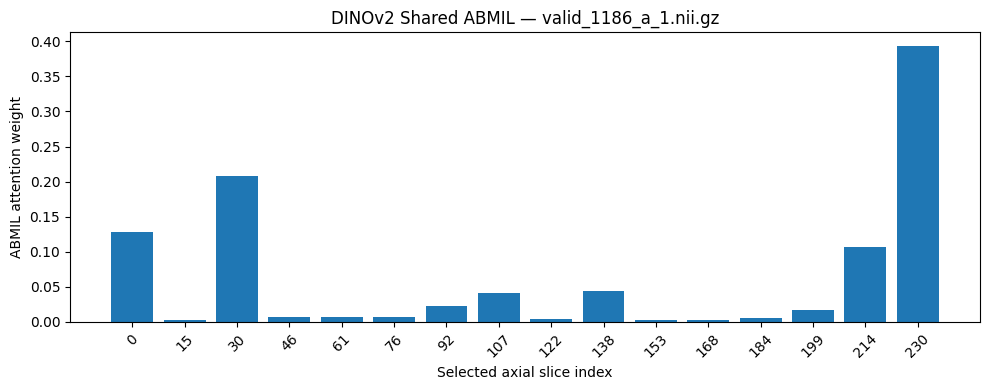

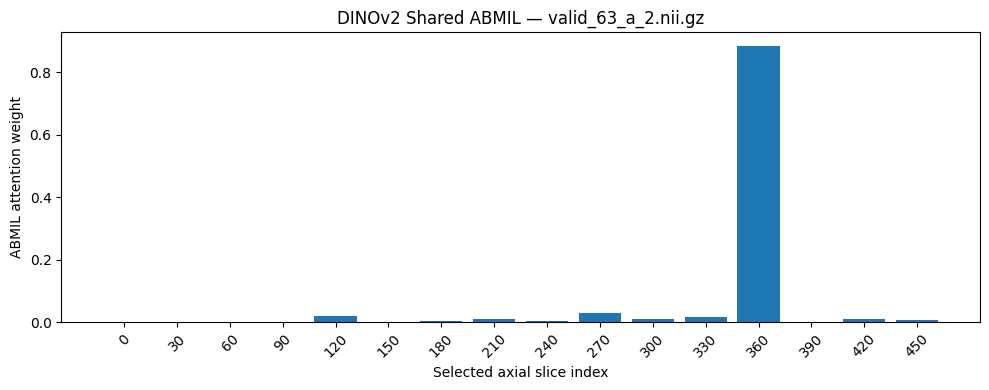

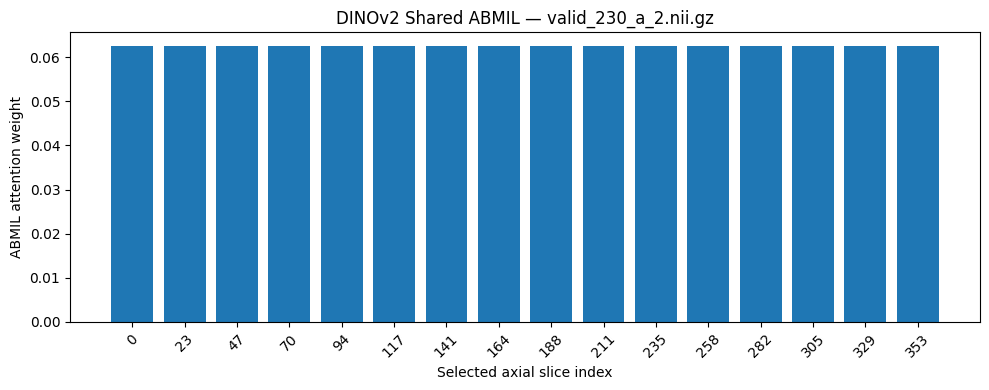

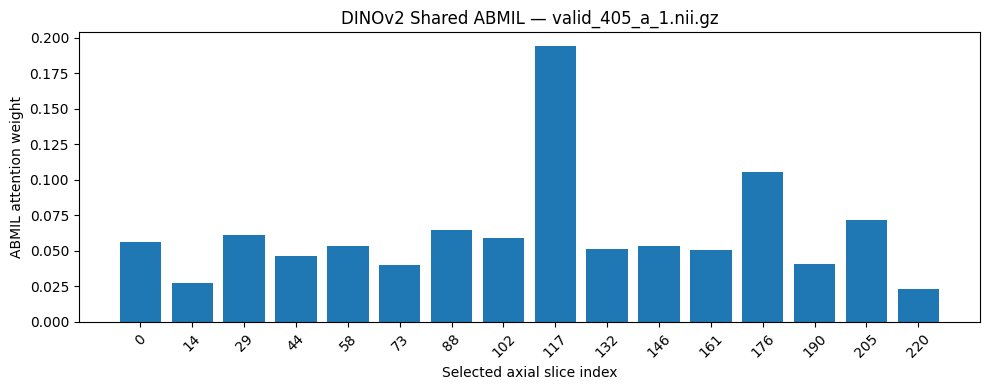

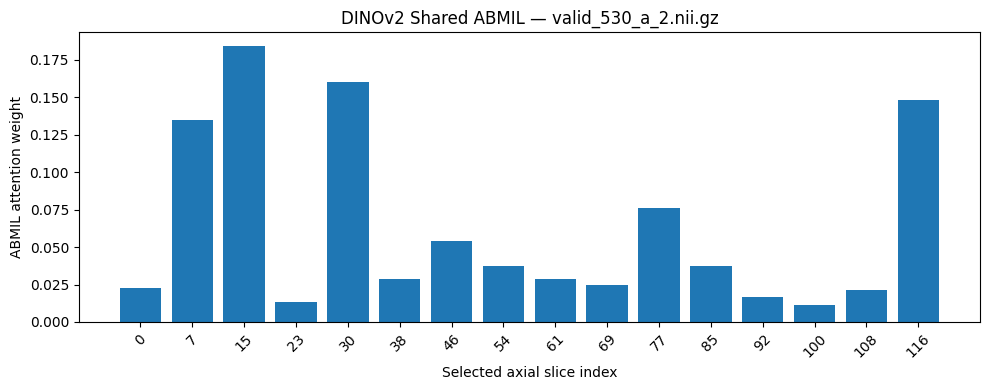

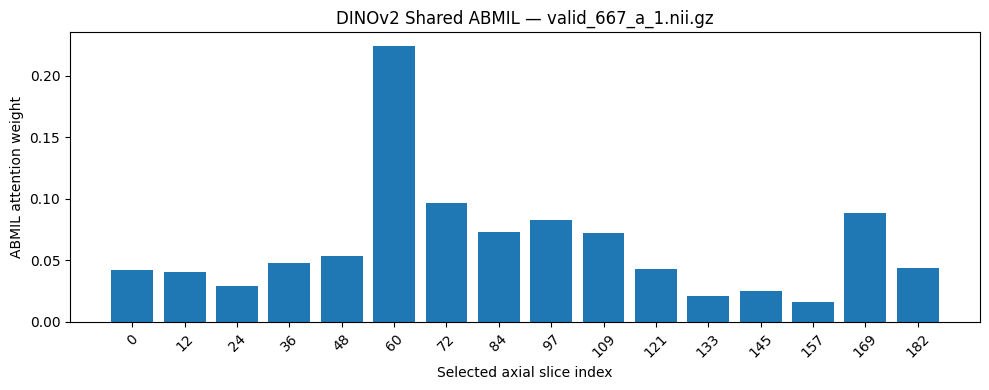

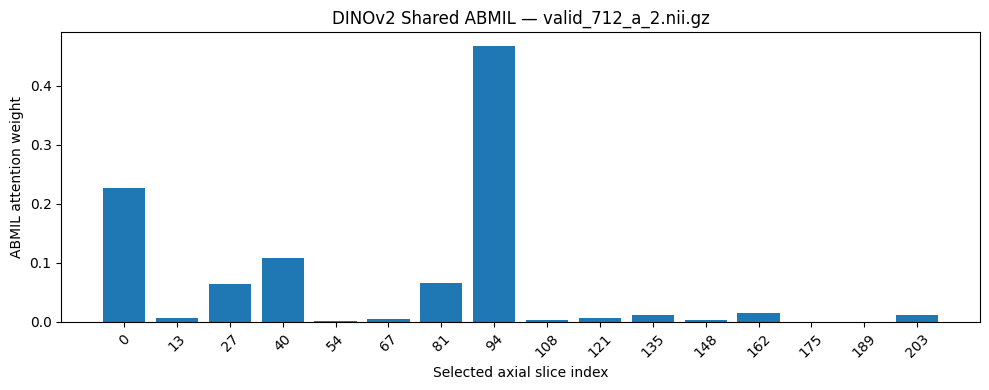

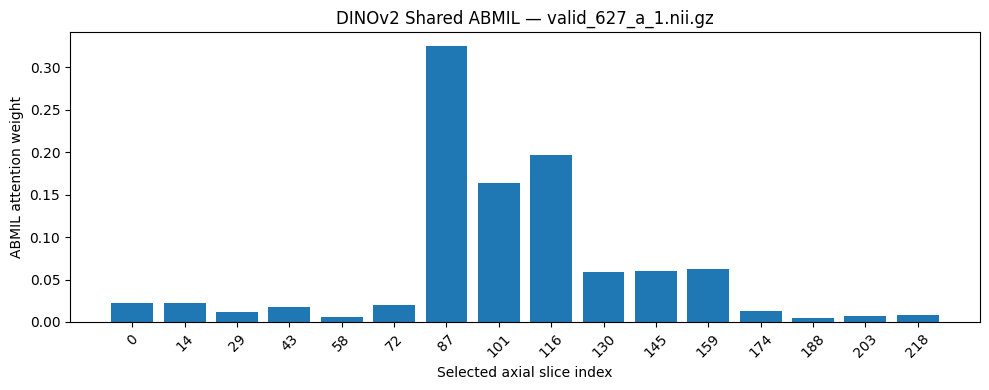

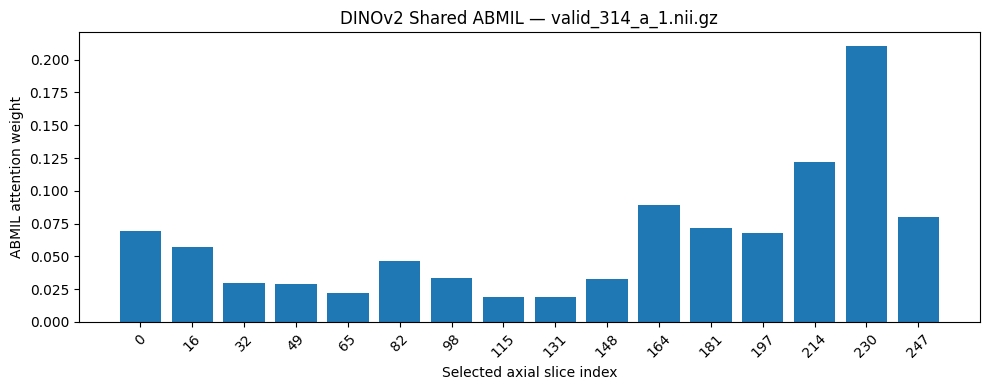

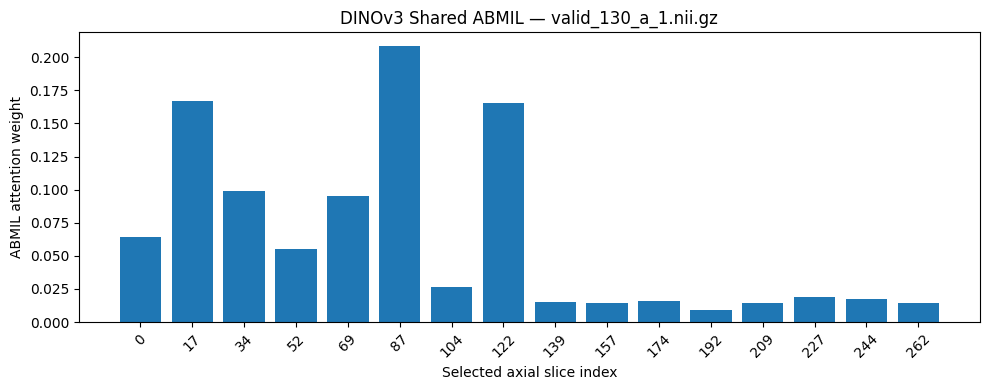

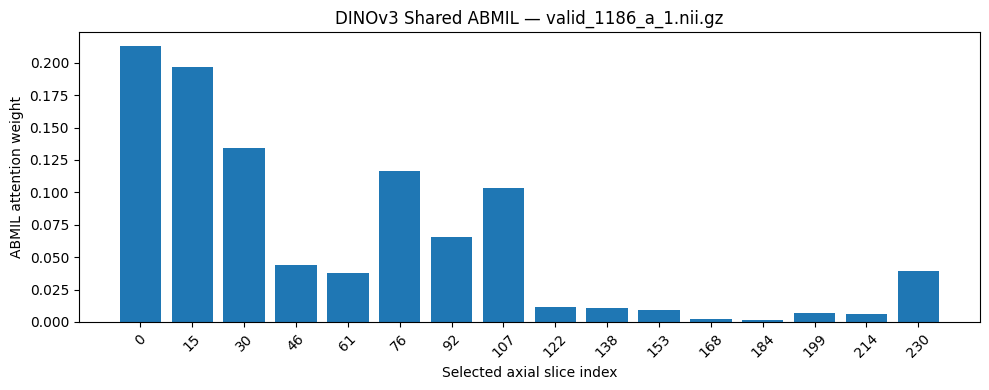

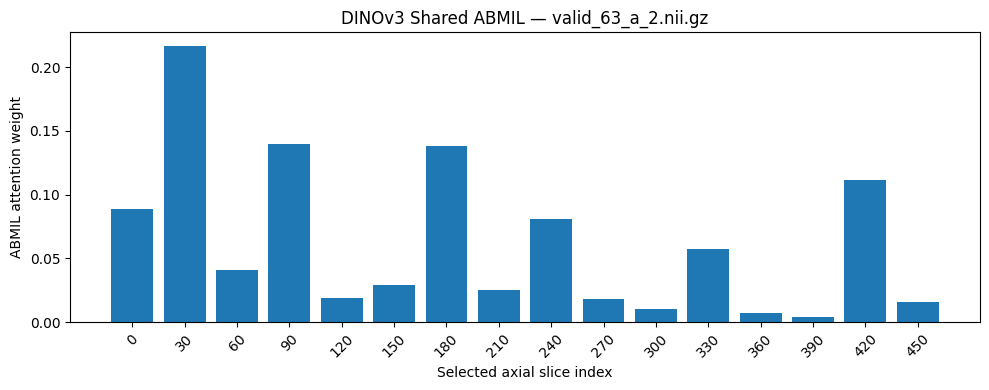

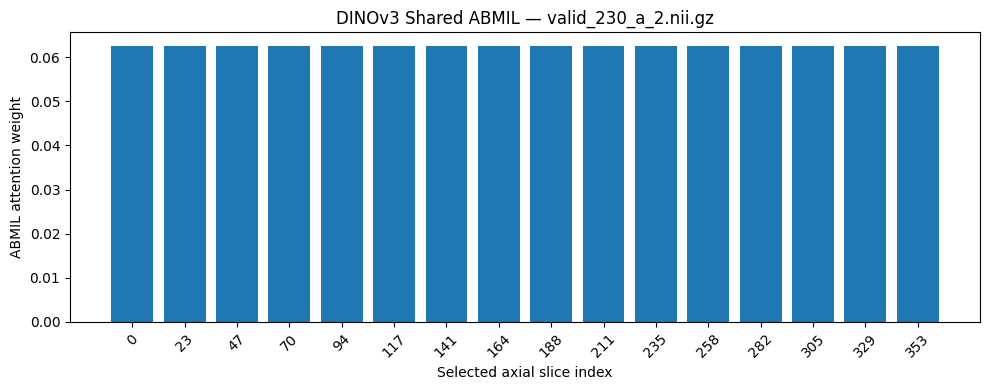

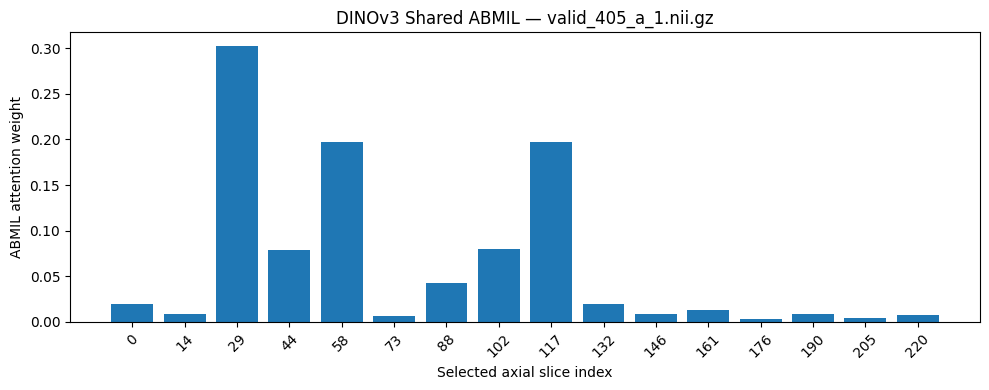

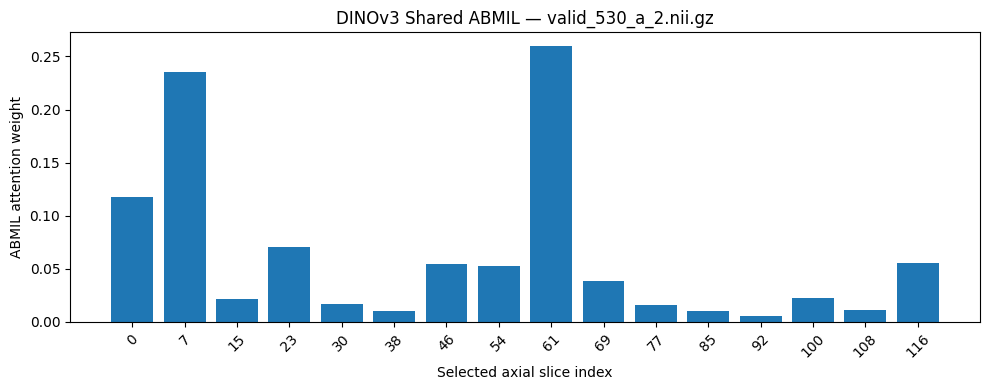

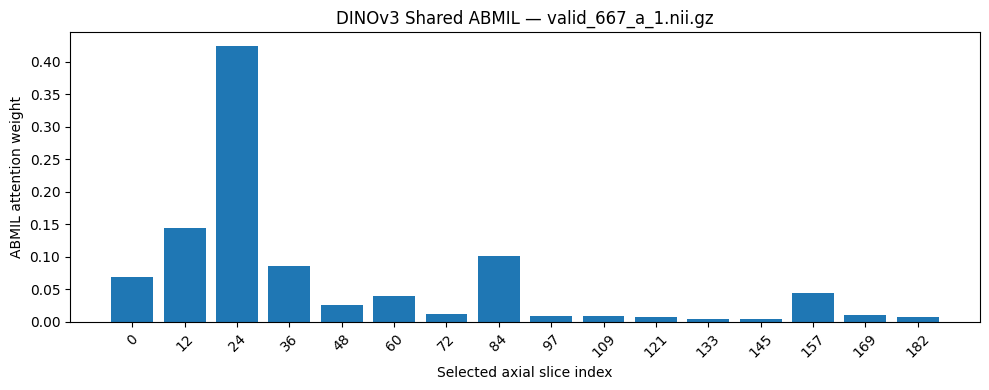

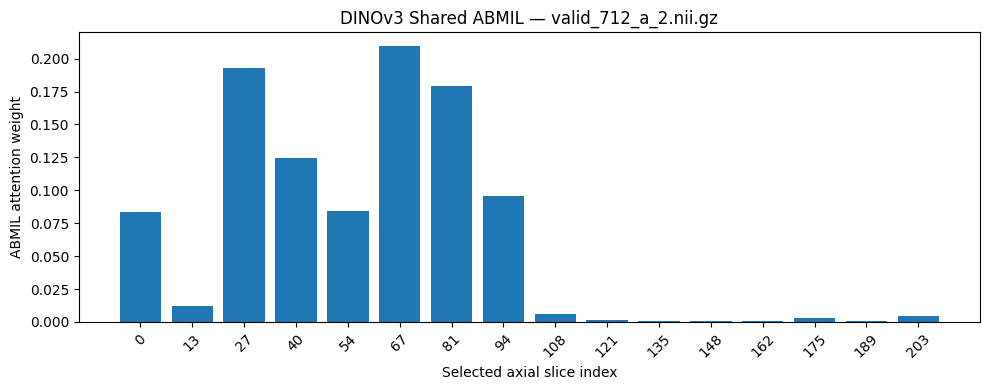

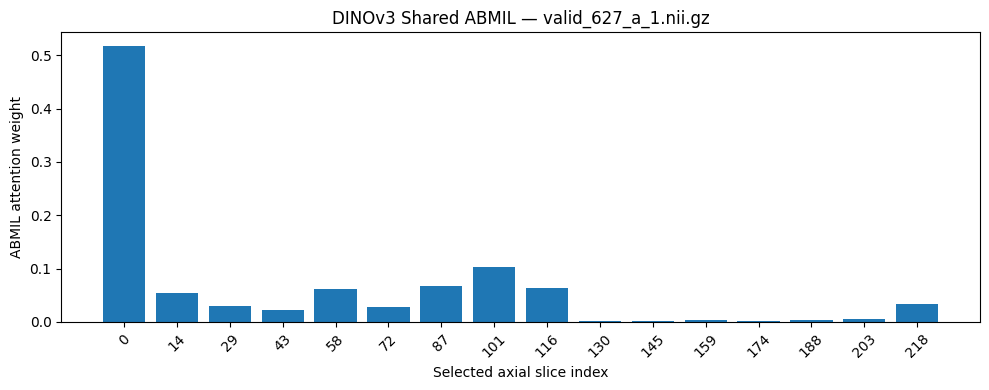

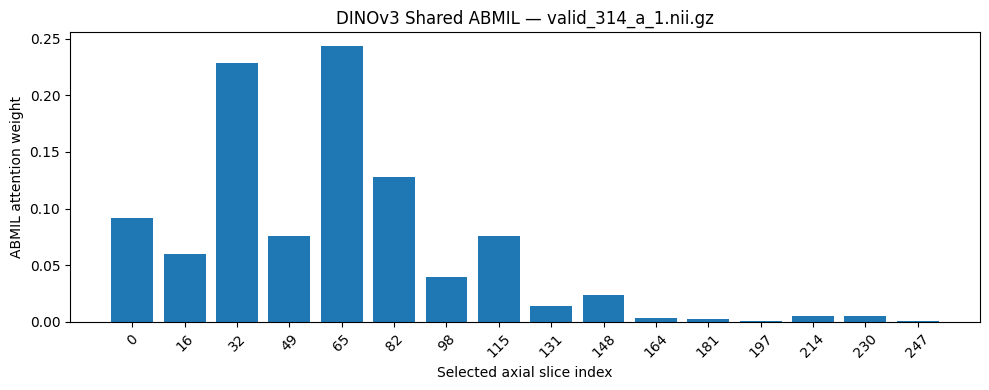

In [65]:
# ============================================================================
# 31. Plot attention weights for validation studies
# ============================================================================

def plot_attention_weights(
    manifest,
    attention,
    indices_list,
    title_prefix
):
    for i, row in manifest.iterrows():

        indices = indices_list[i]

        plt.figure(figsize=(10, 4))

        plt.bar(
            np.arange(len(indices)),
            attention[i]
        )

        plt.xticks(
            np.arange(len(indices)),
            indices,
            rotation=45
        )

        plt.xlabel("Selected axial slice index")
        plt.ylabel("ABMIL attention weight")
        plt.title(
            f"{title_prefix} — {row['volume_id']}"
        )

        plt.tight_layout()
        plt.show()

plot_attention_weights(
    val_manifest,
    v2_val_attention,
    v2_val_indices,
    "DINOv2 Shared ABMIL"
)

plot_attention_weights(
    val_manifest,
    v3_val_attention,
    v3_val_indices,
    "DINOv3 Shared ABMIL"
)

## 32. Display the highest-attention selected slice

This visualization connects the learned ABMIL weight to the corresponding CT slice.

The displayed image is the same three-window representation used as DINO input.

valid_130_a_1.nii.gz | slice=122 | attention=0.1872


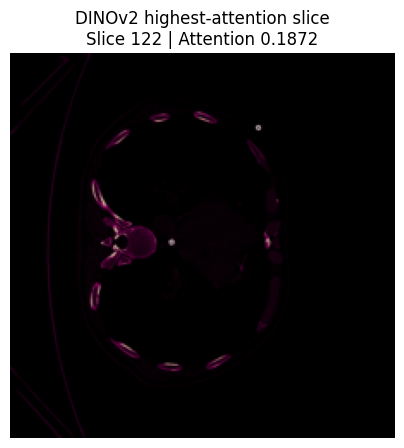

valid_1186_a_1.nii.gz | slice=230 | attention=0.3931


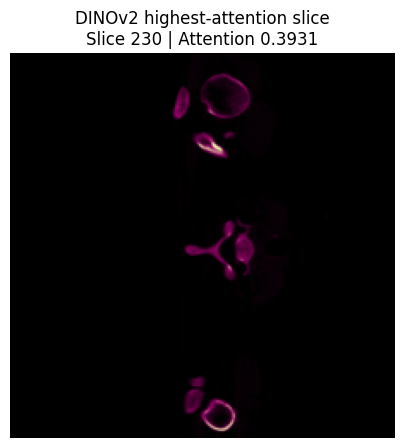

valid_63_a_2.nii.gz | slice=360 | attention=0.8838


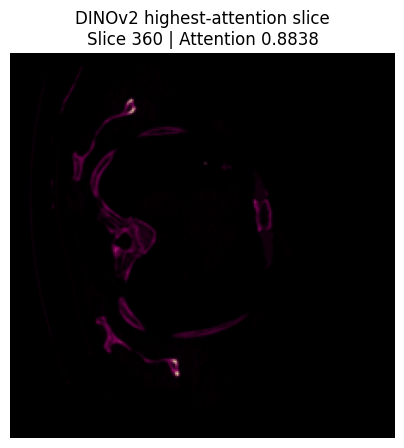

valid_230_a_2.nii.gz | slice=0 | attention=0.0625


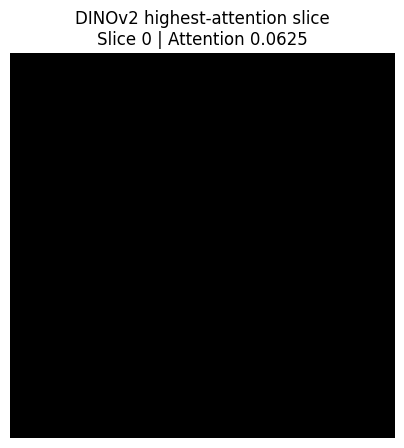

valid_405_a_1.nii.gz | slice=117 | attention=0.1941


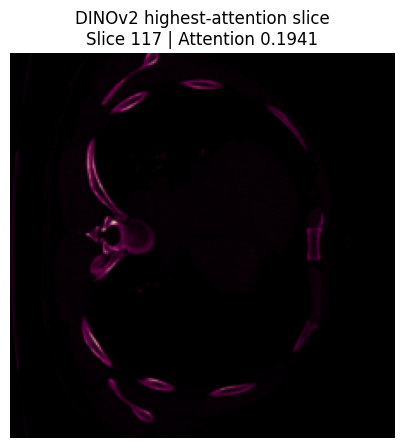

valid_530_a_2.nii.gz | slice=15 | attention=0.1840


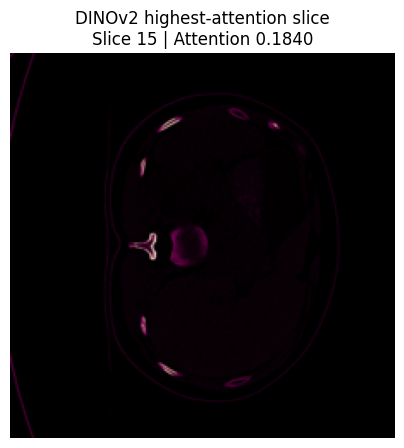

valid_667_a_1.nii.gz | slice=60 | attention=0.2239


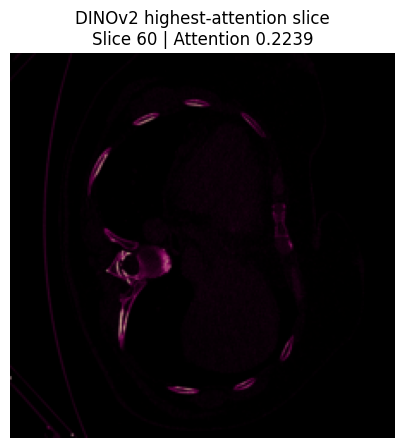

valid_712_a_2.nii.gz | slice=94 | attention=0.4669


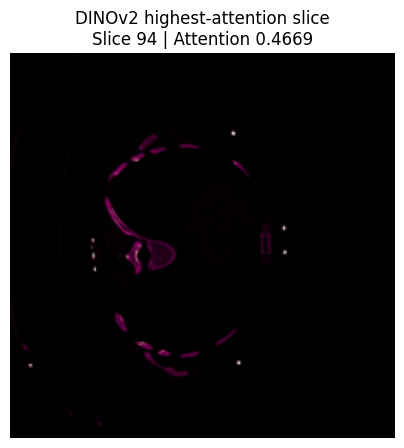

valid_627_a_1.nii.gz | slice=87 | attention=0.3251


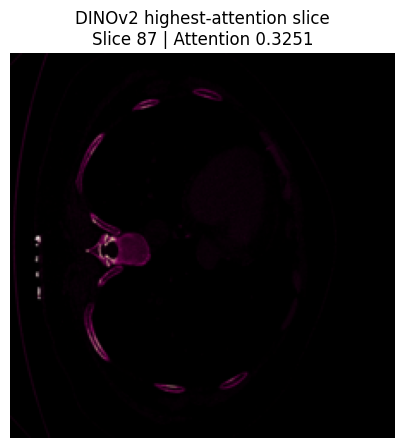

valid_314_a_1.nii.gz | slice=230 | attention=0.2103


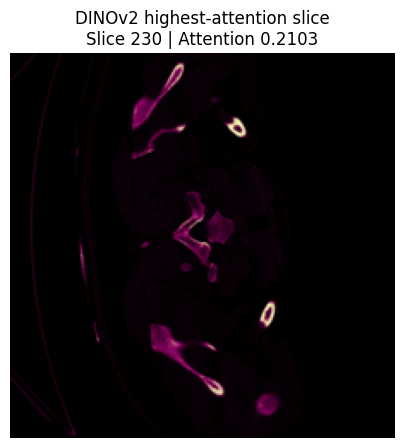

valid_130_a_1.nii.gz | slice=87 | attention=0.2084


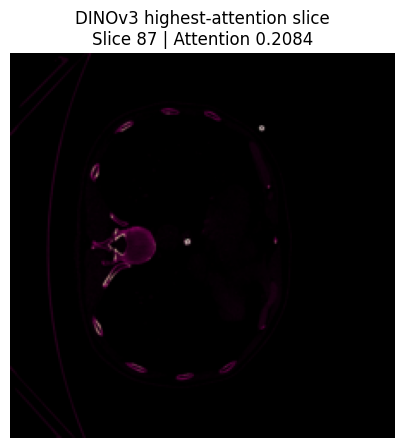

valid_1186_a_1.nii.gz | slice=0 | attention=0.2128


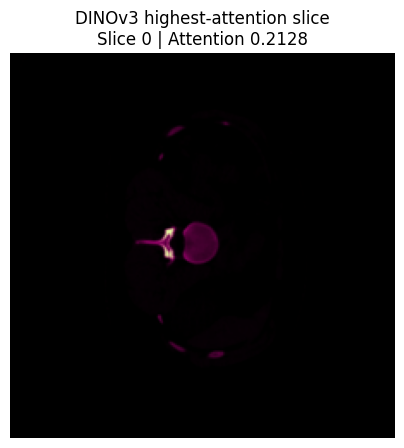

valid_63_a_2.nii.gz | slice=30 | attention=0.2164


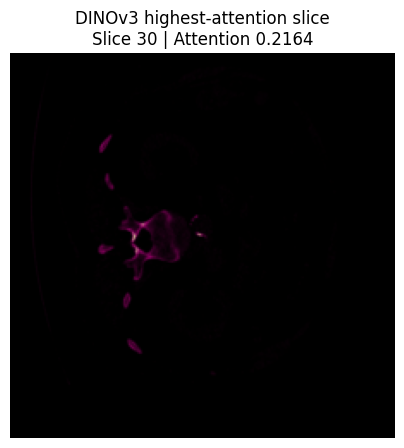

valid_230_a_2.nii.gz | slice=0 | attention=0.0625


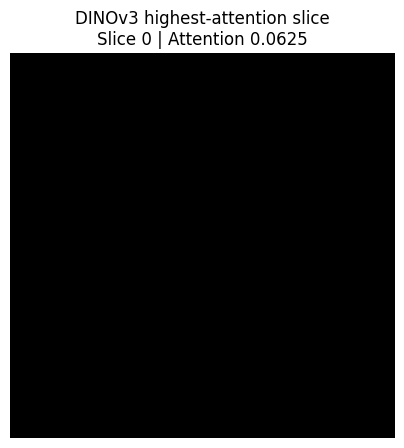

valid_405_a_1.nii.gz | slice=29 | attention=0.3021


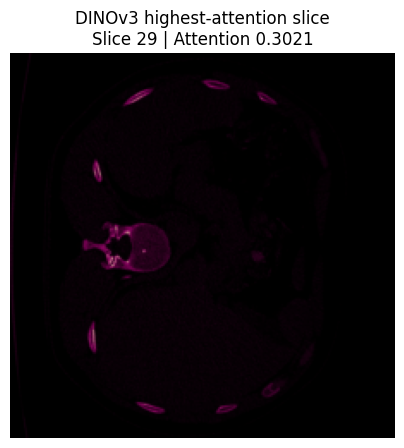

valid_530_a_2.nii.gz | slice=61 | attention=0.2597


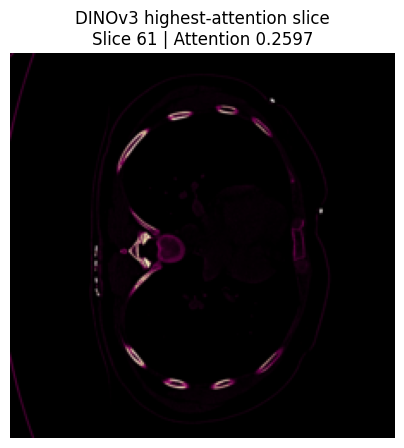

valid_667_a_1.nii.gz | slice=24 | attention=0.4237


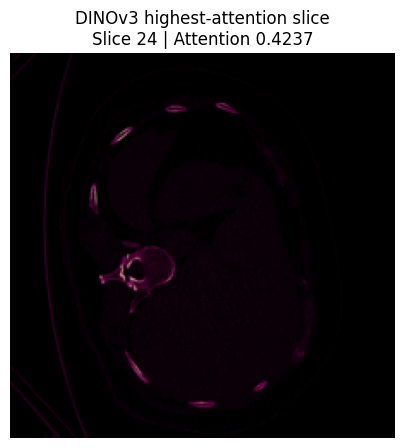

valid_712_a_2.nii.gz | slice=67 | attention=0.2095


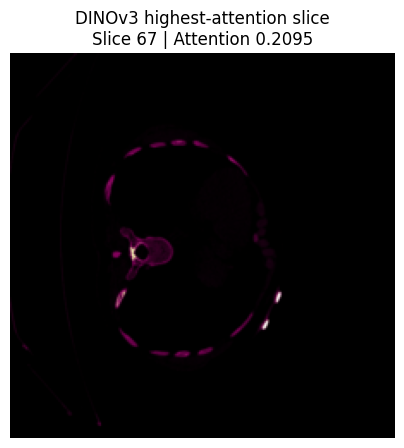

valid_627_a_1.nii.gz | slice=0 | attention=0.5172


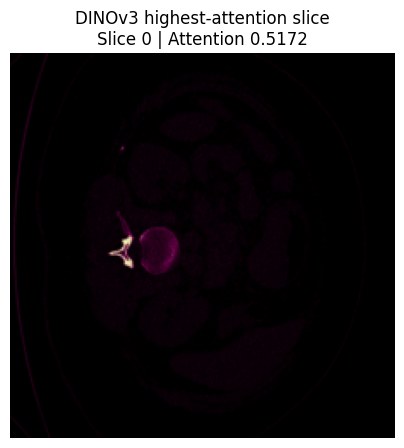

valid_314_a_1.nii.gz | slice=65 | attention=0.2434


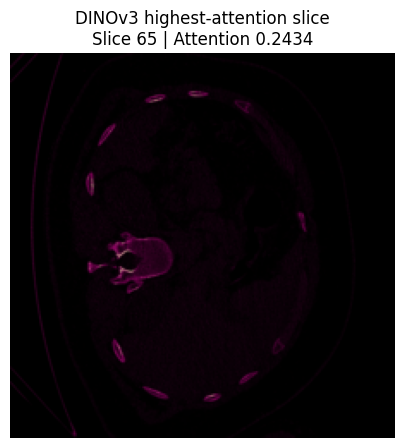

In [66]:
# ============================================================================
# 32. Display the highest-attention validation slice
# ============================================================================

def display_highest_attention_slices(
    manifest,
    attention,
    indices_list,
    title_prefix
):
    for i, row in manifest.iterrows():

        best_position = int(
            np.argmax(attention[i])
        )

        selected_index = int(
            indices_list[i][best_position]
        )

        stored, _ = load_stored_ct(
            row["path"]
        )

        hu = stored_to_hu(
            stored,
            row["rescale_slope"],
            row["rescale_intercept"]
        )

        image = ct_slice_to_3channel(
            hu[:, :, selected_index],
            IMAGE_SIZE
        )

        weight = float(
            attention[i, best_position]
        )

        print(
            f"{row['volume_id']} | "
            f"slice={selected_index} | "
            f"attention={weight:.4f}"
        )

        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"{title_prefix}\n"
            f"Slice {selected_index} | Attention {weight:.4f}"
        )
        plt.show()

display_highest_attention_slices(
    val_manifest,
    v2_val_attention,
    v2_val_indices,
    "DINOv2 highest-attention slice"
)

display_highest_attention_slices(
    val_manifest,
    v3_val_attention,
    v3_val_indices,
    "DINOv3 highest-attention slice"
)

## 33. Compare resource usage

The backbone comparison should not be based only on AUROC.

This smoke test records:

- backbone parameter count
- embedding dimension
- frozen feature-extraction time
- trainable ABMIL + classifier parameters

The final benchmark should additionally record peak VRAM and per-study inference time on the target GPU.

In [67]:
# ============================================================================
# 33. Resource comparison
# ============================================================================

resource_table = pd.DataFrame([
    {
        "Backbone": "DINOv2",
        "Model": DINOV2_ID,
        "Embedding dimension": V2_DIM,
        "Backbone parameters (M)": model_parameter_count(v2_model) / 1e6,
        "Feature extraction time (s)": v2_train_time + v2_val_time,
        "Trainable ABMIL + classifier (K)": (
            trainable_parameter_count(v2_head) / 1e3
        ),
    },
    {
        "Backbone": "DINOv3",
        "Model": DINOV3_ID,
        "Embedding dimension": V3_DIM,
        "Backbone parameters (M)": model_parameter_count(v3_model) / 1e6,
        "Feature extraction time (s)": v3_train_time + v3_val_time,
        "Trainable ABMIL + classifier (K)": (
            trainable_parameter_count(v3_head) / 1e3
        ),
    },
])

display(resource_table)

,Backbone,Model,Embedding dimension,Backbone parameters (M),Feature extraction time (s),Trainable ABMIL + classifier (K)
0,DINOv2,facebook/dinov2-small,384,22.056576,5.871035,56.339
1,DINOv3,facebook/dinov3-vits16-pretrain-lvd1689m,384,21.596544,4.355715,56.339


In [68]:
# ============================================================================
# 34. Save predictions, attention weights, metrics, and experiment metadata
# ============================================================================

np.save(
    RESULT_DIR / "dinov2_abmil_val_probabilities.npy",
    v2_val_probs
)

np.save(
    RESULT_DIR / "dinov3_abmil_val_probabilities.npy",
    v3_val_probs
)

np.save(
    RESULT_DIR / "validation_labels.npy",
    val_y
)

np.save(
    RESULT_DIR / "dinov2_abmil_attention.npy",
    v2_val_attention
)

np.save(
    RESULT_DIR / "dinov3_abmil_attention.npy",
    v3_val_attention
)

v2_per_label.to_csv(
    RESULT_DIR / "dinov2_abmil_per_label_metrics.csv",
    index=False
)

v3_per_label.to_csv(
    RESULT_DIR / "dinov3_abmil_per_label_metrics.csv",
    index=False
)

resource_table.to_csv(
    RESULT_DIR / "resource_comparison.csv",
    index=False
)

summary = {
    "seed": SEED,
    "n_train": N_TRAIN,
    "n_validation": N_VAL,
    "selected_slices_per_study": K_SLICES,
    "image_size": IMAGE_SIZE,
    "aggregation": "Shared ABMIL",
    "loss": "BCEWithLogitsLoss",
    "number_of_labels": NUM_LABELS,
    "dinov2_model": DINOV2_ID,
    "dinov3_model": DINOV3_ID,
    "dinov2_metrics": v2_metrics,
    "dinov3_metrics": v3_metrics,
}

with open(
    RESULT_DIR / "experiment_summary.json",
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print("Saved experiment outputs to:")
print(RESULT_DIR)

Saved experiment outputs to:
/content/drive/MyDrive/CT_RATE_M4/m4_ct_rate/results


# 35. Interpretation and next steps

This notebook now represents the complete M4 smoke-test architecture:

```text
CT-RATE volume
      ↓
per-volume stored-value → HU conversion
      ↓
K=16 uniformly selected slices
      ↓
three-window CT representation
      ↓
224 × 224 × 3
      ↓
frozen DINOv2 / DINOv3
      ↓
K slice embeddings
      ↓
Shared ABMIL
      ├── study representation
      └── slice attention/evidence weights
      ↓
Linear 18-label prediction head
      ↓
18 logits
      ↓
sigmoid probabilities
      ↓
multi-abnormality predictions
```

### What this smoke test establishes

It verifies that:

1. the correct 18 abnormality labels are used,
2. CT-RATE intensity calibration is applied,
3. three-channel CT images can be constructed,
4. DINO features can be extracted and cached,
5. Shared ABMIL can aggregate the selected slices,
6. the 18-label classifier can be trained,
7. attention weights can be visualized,
8. DINOv2 and DINOv3 can be compared under the same downstream pipeline.

### What it does not establish

The experiment is too small to support a scientific model-performance conclusion.

For the real experiments:

- increase the training/validation sample size,
- replace uniform selection with M3's selected indices,
- keep mean pooling as a baseline,
- compare mean pooling vs Shared ABMIL,
- then investigate class-conditioned attention,
- evaluate class imbalance strategies,
- sweep `K ∈ {16, 32, 64, 128, all}`,
- measure peak VRAM and inference time,
- perform the planned accuracy–resource analysis.

The final DINOv2/DINOv3 choice should be based on controlled performance **and** resource measurements, not the smoke-test score alone.

## Interpretation note

The current run is a smoke test using a very small number of studies. Its purpose is to verify the end-to-end representation-learning and classification pipeline. Do not treat the resulting AUROC/AUPRC/F1 values as final research evidence. After the CT-volume path is verified, increase the dataset size and run the controlled experiments defined in the proposal.

## Interpretation

- The notebook now uses **30 training studies and 10 validation studies**.
- Results from this run should still be treated as development evidence because the sample is small for an 18-label task.
- The validation predictions include probabilities for all 18 abnormalities and support TP/FP/FN inspection.
- Mean pooling is intentionally not included in this notebook because the current M4 focus is the Shared ABMIL pipeline. It should be restored later as the zero-parameter aggregation baseline for the formal aggregation ablation.
- M3 slice-selection outputs will replace the temporary uniform slice selection in the integrated experiment.
